<a href="https://colab.research.google.com/github/zgetemur/-Pathway-Guided-Kernel-MLP-Architecture/blob/main/rew1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==============================================================================
# REVIEWER 1 – MAJOR COMMENT 3
# EXACT MANUSCRIPT RA -> AML EXTERNAL TRANSFER
# + MCP-counter cell-composition residualization sensitivity analysis
#
# This script preserves the strategy in the supplied manuscript code:
#   1. Select an 80% stratified RA training subset.
#   2. Train the pathway-guided Kernel-MLP only on RA.
#   3. Apply it directly to all AML/HE target samples.
#   4. Repeat with cell-composition-residualized expression.
#
# NOTE: The supplied code does not freeze source weights and adapt them on AML;
# it is direct source-to-target external transfer. This script intentionally
# preserves that exact strategy for an apples-to-apples sensitivity analysis.
# ==============================================================================

import os
import sys
import gc
import json
import shutil
import random
import warnings
import subprocess
from pathlib import Path

warnings.filterwarnings("ignore")


def run_command(cmd):
    print("$", " ".join(map(str, cmd)))
    subprocess.check_call(cmd)


# ------------------------------------------------------------------------------
# 0) Install only missing packages
# ------------------------------------------------------------------------------
required = {
    "numpy": "numpy",
    "pandas": "pandas",
    "scipy": "scipy",
    "sklearn": "scikit-learn",
    "openpyxl": "openpyxl",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "tensorflow": "tensorflow",
    "gseapy": "gseapy",
    "statsmodels": "statsmodels",
}

for import_name, pip_name in required.items():
    try:
        __import__(import_name)
    except ImportError:
        run_command([sys.executable, "-m", "pip", "install", "-q", pip_name])

if shutil.which("Rscript") is None:
    run_command(["apt-get", "update", "-qq"])
    run_command([
        "apt-get", "install", "-y", "-qq",
        "r-base", "r-base-dev", "libcurl4-openssl-dev",
        "libssl-dev", "libxml2-dev", "libgit2-dev"
    ])

# ------------------------------------------------------------------------------
# 1) Safe Google Drive mount
# ------------------------------------------------------------------------------
from google.colab import drive

MOUNT_POINT = Path("/content/drive")
if (MOUNT_POINT / "MyDrive").is_dir():
    print("Google Drive already mounted.")
else:
    if MOUNT_POINT.exists() and any(MOUNT_POINT.iterdir()):
        backup = Path("/content/drive_pre_mount_backup")
        if backup.exists():
            shutil.rmtree(backup)
        shutil.move(str(MOUNT_POINT), str(backup))
        print("Existing /content/drive moved to:", backup)
    MOUNT_POINT.mkdir(parents=True, exist_ok=True)
    drive.mount(str(MOUNT_POINT), force_remount=True)

# ------------------------------------------------------------------------------
# 2) Imports and settings
# ------------------------------------------------------------------------------
import numpy as np
import pandas as pd
import scipy.stats as st
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.multitest import multipletests
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve, confusion_matrix,
    accuracy_score, balanced_accuracy_score, precision_score,
    recall_score, f1_score
)
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.constraints import NonNeg
from tensorflow.keras.regularizers import l1
from tensorflow.keras.backend import clear_session
from tensorflow.keras.utils import set_random_seed

from gseapy import get_library

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
set_random_seed(SEED)
clear_session()

BASE_DIR = Path("/content/drive/MyDrive/Deneme_2026")
RA_EXPR = BASE_DIR / "combat_corrected_by_gse.xlsx"
RA_PHENO = BASE_DIR / "pheno_raw.xlsx"
AML_EXPR = BASE_DIR / "GSE15061_WithRa.xlsx"
AML_PHENO = BASE_DIR / "GSE15061_phenotype.xlsx"
TOP_PATH_FILE = Path("/content/drive/MyDrive/Ra/yolak_secim_frekansi.xlsx")

SAVE_PATH = BASE_DIR / "REVIEWER1_MAJOR3_EXACT_ORIGINAL_PROTOCOL"
SAVE_PATH.mkdir(parents=True, exist_ok=True)

LIBRARY = "KEGG_2021_Human"
TOP_N = 116
REPEATS = 80          # Change to 80 after validating the 10-run pilot.
EPOCHS = 400
BATCH = 32
LR = 0.001
L1_VAL = 0.001
MIN_GENES = 1
CELL_PC_CUMVAR = 0.80
FIXED_THRESHOLD = 0.5

# full_domain matches the original code's transductive preprocessing style:
# each domain is preprocessed using all samples, without outcome labels.
RESIDUALIZATION_MODE = "full_domain"

print("Output directory:", SAVE_PATH)
print("TOP_N:", TOP_N, "REPEATS:", REPEATS)

# ------------------------------------------------------------------------------
# 3) Helpers
# ------------------------------------------------------------------------------
def pick_col(df, candidates):
    columns = {str(c).lower(): c for c in df.columns}
    for candidate in candidates:
        if candidate.lower() in columns:
            return columns[candidate.lower()]
    return None


def read_expr_xlsx(path):
    df = pd.read_excel(path, engine="openpyxl")
    gene_col = pick_col(df, ["Gen_name", "gene", "genes", "Gene", "GENE"])
    if gene_col is None:
        df = pd.read_excel(path, index_col=0, engine="openpyxl")
    else:
        df = df.set_index(gene_col)

    df.index = df.index.astype(str).str.strip()
    df.columns = df.columns.astype(str).str.strip()
    df = df.apply(pd.to_numeric, errors="coerce")
    valid = (
        df.index.notna() & (df.index != "") &
        (~df.index.str.upper().isin(["NA", "NAN", "NONE"]))
    )
    df = df.loc[valid].dropna(axis=0, how="all")
    df = df.T.fillna(df.median(axis=1)).T
    return df.groupby(level=0, sort=False).mean().astype(float)


def gaussian_kernel(X1, X2=None, sigma=1.0):
    if X2 is None:
        X2 = X1
    distances = euclidean_distances(X1, X2, squared=True)
    return np.exp(-distances / (2.0 * sigma ** 2))


def compute_sigma(X):
    distances = euclidean_distances(X, X, squared=True)
    upper = distances[np.triu_indices(X.shape[0], k=1)]
    upper = upper[upper > 0]
    if upper.size == 0:
        return 1.0
    sigma = float(np.mean(np.sqrt(upper)))
    return sigma if np.isfinite(sigma) and sigma > 0 else 1.0


def build_kernel_mlp(n_support, n_paths):
    inputs = [Input(shape=(n_support,), name=f"path_in_{i}") for i in range(n_paths)]
    bias_input = Input(shape=(1,), name="bias_input")

    shared = Dense(1, use_bias=False, activation=None, name="shared_projection")
    projections = [shared(inp) for inp in inputs]
    bias = Dense(1, use_bias=False, name="bias_weight")(bias_input)
    merged = Concatenate(name="merged")(projections + [bias])

    output = Dense(
        1, activation="sigmoid", use_bias=False,
        kernel_regularizer=l1(L1_VAL), kernel_constraint=NonNeg(),
        name="final_output"
    )(merged)

    model = Model(inputs=inputs + [bias_input], outputs=output)
    model.compile(optimizer=Adam(learning_rate=LR), loss="binary_crossentropy")
    return model


def to_inputs(X):
    return [X[:, i, :] for i in range(X.shape[1])] + [
        np.ones((X.shape[0], 1), dtype=np.float32)
    ]


def best_threshold_youden(y, probabilities):
    fpr, tpr, thresholds = roc_curve(y, probabilities)
    finite = np.isfinite(thresholds)
    fpr, tpr, thresholds = fpr[finite], tpr[finite], thresholds[finite]
    return float(thresholds[np.argmax(tpr - fpr)])


def threshold_metrics(y, probabilities, threshold):
    predicted = (probabilities >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, predicted, labels=[0, 1]).ravel()
    specificity = tn / (tn + fp) if (tn + fp) else np.nan
    return {
        "Accuracy": accuracy_score(y, predicted),
        "Balanced_Accuracy": balanced_accuracy_score(y, predicted),
        "Precision": precision_score(y, predicted, zero_division=0),
        "Recall": recall_score(y, predicted, zero_division=0),
        "Specificity": specificity,
        "F1": f1_score(y, predicted, zero_division=0),
        "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
    }


def complete_metrics(y, probabilities):
    result = {
        "AUROC": roc_auc_score(y, probabilities),
        "PR_AUC": average_precision_score(y, probabilities),
    }

    fixed = threshold_metrics(y, probabilities, FIXED_THRESHOLD)
    for key, value in fixed.items():
        result[f"{key}_at_0.5"] = value

    # Reproduces the supplied manuscript code, but is labelled exploratory
    # because it uses target labels to calibrate the threshold.
    target_threshold = best_threshold_youden(y, probabilities)
    result["Target_calibrated_threshold"] = target_threshold
    calibrated = threshold_metrics(y, probabilities, target_threshold)
    for key, value in calibrated.items():
        result[f"{key}_target_calibrated"] = value

    return result


def bh_fdr(values):
    values = np.asarray(values, dtype=float)
    output = np.full(values.shape, np.nan)
    valid = np.isfinite(values)
    if valid.any():
        output[valid] = multipletests(values[valid], method="fdr_bh")[1]
    return output


def fit_cell_pca(cell_scores):
    scaler = StandardScaler()
    z = scaler.fit_transform(cell_scores)
    pca_full = PCA().fit(z)
    cumulative = np.cumsum(pca_full.explained_variance_ratio_)
    n_components = int(np.searchsorted(cumulative, CELL_PC_CUMVAR) + 1)
    pca = PCA(n_components=n_components)
    scores = pca.fit_transform(z)
    return scores, n_components, cumulative[n_components - 1]


def residualize_domain(expression, cell_scores):
    """Residualize all genes against MCP-counter PCs within one domain."""
    pc_scores, n_components, explained = fit_cell_pca(cell_scores)
    regression = LinearRegression()
    regression.fit(pc_scores, expression.T.values)
    predicted = regression.predict(pc_scores)
    residuals = expression.T.values - predicted
    residual_df = pd.DataFrame(
        residuals.T, index=expression.index, columns=expression.columns
    )
    return residual_df, n_components, explained


def independently_scale_domains(ra_expression, aml_expression):
    """Exact scaling strategy from the supplied manuscript code."""
    ra_scaler = StandardScaler().fit(ra_expression.T)
    ra_scaled = pd.DataFrame(
        ra_scaler.transform(ra_expression.T).T,
        index=ra_expression.index, columns=ra_expression.columns
    )

    aml_scaler = StandardScaler().fit(aml_expression.T)
    aml_scaled = pd.DataFrame(
        aml_scaler.transform(aml_expression.T).T,
        index=aml_expression.index, columns=aml_expression.columns
    )
    return ra_scaled, aml_scaled


def make_external_kernels(ra_scaled, aml_scaled, train_columns, aml_columns, active_paths):
    train_kernels, target_kernels = [], []
    for _, genes in active_paths:
        train_matrix = ra_scaled.loc[genes, train_columns].T
        target_matrix = aml_scaled.loc[genes, aml_columns].T
        sigma = compute_sigma(train_matrix)
        train_kernels.append(gaussian_kernel(train_matrix, sigma=sigma))
        target_kernels.append(gaussian_kernel(target_matrix, train_matrix, sigma=sigma))

    X_train = np.transpose(np.stack(train_kernels), (1, 0, 2)).astype(np.float32)
    X_target = np.transpose(np.stack(target_kernels), (1, 0, 2)).astype(np.float32)
    return X_train, X_target


def run_condition(condition_name, ra_expression, aml_expression, ra_cell_scores,
                  aml_cell_scores, active_paths, ra_samples, aml_samples,
                  y_ra, y_aml, residualized):
    rows = []
    predictions = []

    if residualized:
        ra_condition, ra_n_pc, ra_var = residualize_domain(
            ra_expression, ra_cell_scores
        )
        aml_condition, aml_n_pc, aml_var = residualize_domain(
            aml_expression, aml_cell_scores
        )
    else:
        ra_condition = ra_expression.copy()
        aml_condition = aml_expression.copy()
        ra_n_pc = aml_n_pc = 0
        ra_var = aml_var = 0.0

    # Same entire-domain scaling as the supplied code.
    ra_scaled, aml_scaled = independently_scale_domains(
        ra_condition, aml_condition
    )

    for repeat in range(REPEATS):
        split_seed = SEED + repeat
        train_indices, _ = train_test_split(
            np.arange(len(ra_samples)), test_size=0.20,
            stratify=y_ra, random_state=split_seed
        )

        train_columns = np.asarray(ra_samples)[train_indices].tolist()
        y_train = y_ra[train_indices]

        X_train, X_aml = make_external_kernels(
            ra_scaled, aml_scaled, train_columns, aml_samples, active_paths
        )

        clear_session()
        set_random_seed(split_seed)

        class_weights = dict(enumerate(compute_class_weight(
            class_weight="balanced", classes=np.unique(y_train), y=y_train
        )))

        model = build_kernel_mlp(X_train.shape[2], X_train.shape[1])
        model.fit(
            to_inputs(X_train), y_train,
            epochs=EPOCHS, batch_size=BATCH, verbose=0,
            class_weight=class_weights, shuffle=True
        )

        probabilities = model.predict(to_inputs(X_aml), verbose=0).flatten()
        metrics = complete_metrics(y_aml, probabilities)
        metrics.update({
            "Condition": condition_name,
            "Repeat": repeat + 1,
            "RA_cell_PCs": ra_n_pc,
            "RA_cell_variance": ra_var,
            "AML_cell_PCs": aml_n_pc,
            "AML_cell_variance": aml_var,
        })
        rows.append(metrics)

        for sample, label, probability in zip(aml_samples, y_aml, probabilities):
            predictions.append({
                "Condition": condition_name,
                "Repeat": repeat + 1,
                "Sample": sample,
                "True_label": int(label),
                "Predicted_probability_AML": float(probability),
            })

        print(
            f"{condition_name} rep {repeat + 1}/{REPEATS} | "
            f"AUROC={metrics['AUROC']:.4f} | "
            f"PR-AUC={metrics['PR_AUC']:.4f} | "
            f"F1@0.5={metrics['F1_at_0.5']:.4f} | "
            f"F1 target-cal={metrics['F1_target_calibrated']:.4f}"
        )

        del model, X_train, X_aml
        clear_session()
        gc.collect()

    return pd.DataFrame(rows), pd.DataFrame(predictions)


# ------------------------------------------------------------------------------
# 4) Check files
# ------------------------------------------------------------------------------
input_files = {
    "RA expression": RA_EXPR,
    "RA phenotype": RA_PHENO,
    "AML expression": AML_EXPR,
    "AML phenotype": AML_PHENO,
    "Pathway frequency": TOP_PATH_FILE,
}

missing = []
for label, path in input_files.items():
    print(f"{label:20s}: {path.exists()} | {path}")
    if not path.exists():
        missing.append(f"{label}: {path}")
if missing:
    raise FileNotFoundError("Missing files:\n" + "\n".join(missing))

# ------------------------------------------------------------------------------
# 5) Load data
# ------------------------------------------------------------------------------
print("\n[1/10] LOAD DATA")
expr_ra = read_expr_xlsx(RA_EXPR)
expr_aml = read_expr_xlsx(AML_EXPR)
ph_ra = pd.read_excel(RA_PHENO, engine="openpyxl")
ph_aml = pd.read_excel(AML_PHENO, engine="openpyxl")

ra_sample_col = pick_col(ph_ra, ["sample"])
ra_group_col = pick_col(ph_ra, ["group_raw", "group", "label"])
aml_sample_col = pick_col(ph_aml, ["sample", "Sample"])
aml_group_col = pick_col(ph_aml, ["group_raw", "group", "label"])

if ra_sample_col is None or ra_group_col is None:
    raise KeyError(f"RA phenotype columns not found: {list(ph_ra.columns)}")
if aml_sample_col is None or aml_group_col is None:
    raise KeyError(f"AML phenotype columns not found: {list(ph_aml.columns)}")

for df, sample_col, group_col in [
    (ph_ra, ra_sample_col, ra_group_col),
    (ph_aml, aml_sample_col, aml_group_col),
]:
    df[sample_col] = df[sample_col].astype(str).str.strip()
    df[group_col] = df[group_col].astype(str).str.strip()

ph_ra = ph_ra.loc[ph_ra[ra_group_col].isin(["RA", "HE"])].copy()

# Explicit AML/HE filtering; MDS is never relabelled as healthy.
aml_upper = ph_aml[aml_group_col].str.upper()
# NumPy 2.x-compatible phenotype normalization.
# MDS and unmatched samples remain missing and are excluded below.
ph_aml["group_norm"] = pd.Series(
    pd.NA,
    index=ph_aml.index,
    dtype="object",
)

is_aml = (
    aml_upper.eq("AML")
    | aml_upper.str.contains(
        "ACUTE MYELOID|ACUTE MYELOGENOUS",
        regex=True,
        na=False,
    )
)

is_he = (
    aml_upper.eq("HE")
    | aml_upper.str.contains(
        "HEALTHY|NORMAL|CONTROL|DONOR|NON[- .]?LEUK",
        regex=True,
        na=False,
    )
)

ph_aml.loc[is_aml, "group_norm"] = "AML"
ph_aml.loc[is_he & ~is_aml, "group_norm"] = "HE"
ph_aml = ph_aml.loc[ph_aml["group_norm"].isin(["AML", "HE"])].copy()

ra_samples = [s for s in expr_ra.columns if s in set(ph_ra[ra_sample_col])]
aml_samples = [s for s in expr_aml.columns if s in set(ph_aml[aml_sample_col])]
expr_ra = expr_ra.loc[:, ra_samples]
expr_aml = expr_aml.loc[:, aml_samples]

ra_group = ph_ra.set_index(ra_sample_col).loc[ra_samples, ra_group_col]
aml_group = ph_aml.set_index(aml_sample_col).loc[aml_samples, "group_norm"]

y_ra = np.array([1 if group == "RA" else 0 for group in ra_group], dtype=int)
y_aml = np.array([1 if group == "AML" else 0 for group in aml_group], dtype=int)

print("RA", len(ra_samples), ra_group.value_counts().to_dict())
print("AML", len(aml_samples), aml_group.value_counts().to_dict())

common_genes = sorted(set(expr_ra.index) & set(expr_aml.index))
expr_ra = expr_ra.loc[common_genes]
expr_aml = expr_aml.loc[common_genes]
print("Common genes", len(common_genes))

if len(ra_samples) != 195 or y_ra.sum() != 163 or (y_ra == 0).sum() != 32:
    raise ValueError("Unexpected RA cohort composition.")
if len(aml_samples) != 195 or y_aml.sum() != 163 or (y_aml == 0).sum() != 32:
    raise ValueError("Unexpected AML cohort composition.")

# ------------------------------------------------------------------------------
# 6) MCP-counter for both domains
# ------------------------------------------------------------------------------
print("\n[2/10] MCP-COUNTER BOTH DOMAINS")
ra_csv = SAVE_PATH / "_RA_expression_for_MCP.csv"
aml_csv = SAVE_PATH / "_AML_expression_for_MCP.csv"

for expression, path in [(expr_ra, ra_csv), (expr_aml, aml_csv)]:
    export = expression.copy()
    export.insert(0, "Gene", export.index)
    export.to_csv(path, index=False)

r_code = r'''
args <- commandArgs(trailingOnly=TRUE)
ra_file <- args[1]
aml_file <- args[2]
out_dir <- args[3]
options(repos=c(CRAN="https://cloud.r-project.org"), timeout=3000)
if (!requireNamespace("remotes", quietly=TRUE)) install.packages("remotes")
if (!requireNamespace("BiocManager", quietly=TRUE)) install.packages("BiocManager")
if (!requireNamespace("limma", quietly=TRUE)) {
  BiocManager::install("limma", ask=FALSE, update=FALSE)
}
if (!requireNamespace("MCPcounter", quietly=TRUE)) {
  remotes::install_github(
    repo="ebecht/MCPcounter", ref="master", subdir="Source",
    upgrade="never", dependencies=TRUE
  )
}
suppressPackageStartupMessages({library(limma); library(MCPcounter)})
read_expression <- function(path) {
  d <- read.csv(path, check.names=FALSE, stringsAsFactors=FALSE)
  genes <- trimws(as.character(d[[1]])); d[[1]] <- NULL
  x <- as.matrix(d); storage.mode(x) <- "double"; rownames(x) <- genes
  limma::avereps(x, ID=rownames(x))
}
ra <- read_expression(ra_file)
aml <- read_expression(aml_file)
mcp_ra <- MCPcounter::MCPcounter.estimate(ra, featuresType="HUGO_symbols")
mcp_aml <- MCPcounter::MCPcounter.estimate(aml, featuresType="HUGO_symbols")
write.csv(
  cbind(Cell_population=rownames(mcp_ra), as.data.frame(mcp_ra)),
  file.path(out_dir, "02_MCPcounter_RA.csv"), row.names=FALSE
)
write.csv(
  cbind(Cell_population=rownames(mcp_aml), as.data.frame(mcp_aml)),
  file.path(out_dir, "03_MCPcounter_AML.csv"), row.names=FALSE
)
writeLines(capture.output(sessionInfo()), file.path(out_dir, "R_SessionInfo.txt"))
'''

r_script = SAVE_PATH / "_run_mcp_both_domains.R"
r_script.write_text(r_code, encoding="utf-8")
run_command(["Rscript", str(r_script), str(ra_csv), str(aml_csv), str(SAVE_PATH)])

mcp_ra = pd.read_csv(SAVE_PATH / "02_MCPcounter_RA.csv").set_index("Cell_population")
mcp_aml = pd.read_csv(SAVE_PATH / "03_MCPcounter_AML.csv").set_index("Cell_population")
mcp_ra = mcp_ra.loc[:, ra_samples].astype(float)
mcp_aml = mcp_aml.loc[:, aml_samples].astype(float)
print("MCP RA", mcp_ra.shape, "MCP AML", mcp_aml.shape)

ra_cell_scores = mcp_ra.T.values
aml_cell_scores = mcp_aml.T.values

# ------------------------------------------------------------------------------
# 7) Pathways
# ------------------------------------------------------------------------------
print("\n[3/10] PATHWAYS")
frequency = pd.read_excel(TOP_PATH_FILE, engine="openpyxl")
pathway_col = pick_col(frequency, ["Pathway"])
count_col = pick_col(frequency, ["Selection_Count", "Count"])
if pathway_col is None or count_col is None:
    raise KeyError(f"Pathway columns not found: {list(frequency.columns)}")

top_paths = (
    frequency.sort_values(count_col, ascending=False)
    .head(TOP_N)[pathway_col].astype(str).str.strip().tolist()
)
kegg = get_library(name=LIBRARY, organism="Human")
active_paths = []
for pathway in top_paths:
    if pathway in kegg:
        genes = sorted(set(kegg[pathway]) & set(common_genes))
        if len(genes) >= MIN_GENES:
            active_paths.append((pathway, genes))
print("Usable", len(active_paths))
if len(active_paths) != TOP_N:
    raise ValueError(f"Only {len(active_paths)}/{TOP_N} pathways are usable.")

pd.DataFrame({
    "Pathway": [p for p, _ in active_paths],
    "Genes_in_common_matrix": [len(g) for _, g in active_paths],
}).to_excel(SAVE_PATH / "04_Active_Pathways.xlsx", index=False)

# ------------------------------------------------------------------------------
# 8) Pathway-cell correlations in both domains
# ------------------------------------------------------------------------------
print("\n[4/10] PATHWAY-CELL CORRELATIONS")
correlation_rows = []
for domain, expression, mcp in [("RA", expr_ra, mcp_ra), ("AML", expr_aml, mcp_aml)]:
    for pathway, genes in active_paths:
        pathway_score = expression.loc[genes].mean(axis=0)
        for cell_population in mcp.index:
            rho, p_value = st.spearmanr(
                pathway_score.loc[mcp.columns].values,
                mcp.loc[cell_population].values,
            )
            correlation_rows.append({
                "Domain": domain,
                "Pathway": pathway,
                "Cell_population": cell_population,
                "Spearman_rho": rho,
                "p_value": p_value,
            })

correlations = pd.DataFrame(correlation_rows)
correlations["FDR_within_domain"] = correlations.groupby("Domain")["p_value"].transform(
    lambda values: bh_fdr(values.values)
)
correlations["Absolute_rho"] = correlations["Spearman_rho"].abs()
correlations.to_excel(
    SAVE_PATH / "05_Pathway_Cell_Correlations_Both_Domains.xlsx", index=False
)

# ------------------------------------------------------------------------------
# 9) Original and residualized external transfer
# ------------------------------------------------------------------------------
print("\n[5/10] ORIGINAL EXPRESSION")
original_metrics, original_predictions = run_condition(
    "Original_expression", expr_ra, expr_aml,
    ra_cell_scores, aml_cell_scores, active_paths,
    ra_samples, aml_samples, y_ra, y_aml, residualized=False
)

print("\n[6/10] CELL-RESIDUALIZED EXPRESSION")
residualized_metrics, residualized_predictions = run_condition(
    "Cell_residualized_expression", expr_ra, expr_aml,
    ra_cell_scores, aml_cell_scores, active_paths,
    ra_samples, aml_samples, y_ra, y_aml, residualized=True
)

all_metrics = pd.concat([original_metrics, residualized_metrics], ignore_index=True)
all_predictions = pd.concat([original_predictions, residualized_predictions], ignore_index=True)
all_metrics.to_excel(SAVE_PATH / "06_PerRepeat_Original_vs_Residualized.xlsx", index=False)
all_predictions.to_excel(SAVE_PATH / "06B_All_Target_Predictions.xlsx", index=False)

# ------------------------------------------------------------------------------
# 10) Paired comparison
# ------------------------------------------------------------------------------
print("\n[7/10] PERFORMANCE COMPARISON")
metrics_to_compare = [
    "AUROC", "PR_AUC",
    "Accuracy_at_0.5", "Balanced_Accuracy_at_0.5",
    "Precision_at_0.5", "Recall_at_0.5", "Specificity_at_0.5", "F1_at_0.5",
    "Accuracy_target_calibrated", "Balanced_Accuracy_target_calibrated",
    "Precision_target_calibrated", "Recall_target_calibrated",
    "Specificity_target_calibrated", "F1_target_calibrated",
]

original_ordered = original_metrics.sort_values("Repeat")
residualized_ordered = residualized_metrics.sort_values("Repeat")
comparison_rows = []

for metric in metrics_to_compare:
    original_values = original_ordered[metric].values
    residual_values = residualized_ordered[metric].values
    delta = residual_values - original_values
    try:
        p_value = st.wilcoxon(
            residual_values, original_values,
            zero_method="wilcox", alternative="two-sided"
        ).pvalue
    except Exception:
        p_value = np.nan

    comparison_rows.append({
        "Metric": metric,
        "Original_mean": np.mean(original_values),
        "Original_SD": np.std(original_values, ddof=1),
        "Original_median": np.median(original_values),
        "Residualized_mean": np.mean(residual_values),
        "Residualized_SD": np.std(residual_values, ddof=1),
        "Residualized_median": np.median(residual_values),
        "Mean_delta_residualized_minus_original": np.mean(delta),
        "Median_delta": np.median(delta),
        "Paired_Wilcoxon_p": p_value,
    })

comparison = pd.DataFrame(comparison_rows)
comparison["Paired_Wilcoxon_FDR"] = bh_fdr(comparison["Paired_Wilcoxon_p"])
comparison.to_excel(SAVE_PATH / "07_Paired_Performance_Comparison.xlsx", index=False)
print(comparison.to_string(index=False))

# ------------------------------------------------------------------------------
# 11) Figures
# ------------------------------------------------------------------------------
print("\n[8/10] FIGURES")
plot_data = all_metrics.melt(
    id_vars=["Condition", "Repeat"],
    value_vars=["AUROC", "PR_AUC", "Balanced_Accuracy_at_0.5", "F1_at_0.5"],
    var_name="Metric", value_name="Value"
)
plt.figure(figsize=(12, 6))
sns.boxplot(data=plot_data, x="Metric", y="Value", hue="Condition")
sns.stripplot(
    data=plot_data, x="Metric", y="Value", hue="Condition",
    dodge=True, alpha=0.30, size=3, legend=False
)
plt.ylim(0, 1.03)
plt.title("RA→AML external transfer before and after cell-composition residualization")
plt.tight_layout()
plt.savefig(SAVE_PATH / "Figure_1_Performance_Comparison.png", dpi=300, bbox_inches="tight")
plt.savefig(SAVE_PATH / "Figure_1_Performance_Comparison.pdf", bbox_inches="tight")
plt.close()

paired_auc = pd.DataFrame({
    "Repeat": original_ordered["Repeat"].values,
    "Original": original_ordered["AUROC"].values,
    "Residualized": residualized_ordered["AUROC"].values,
})
plt.figure(figsize=(7, 6))
for _, row in paired_auc.iterrows():
    plt.plot([0, 1], [row["Original"], row["Residualized"]], alpha=0.25)
plt.scatter(np.zeros(len(paired_auc)), paired_auc["Original"], label="Original")
plt.scatter(np.ones(len(paired_auc)), paired_auc["Residualized"], label="Cell residualized")
plt.xticks([0, 1], ["Original", "Cell residualized"])
plt.ylabel("External AML AUROC")
plt.title("Paired AUROC change across RA training splits")
plt.legend()
plt.tight_layout()
plt.savefig(SAVE_PATH / "Figure_2_Paired_AUROC_Change.png", dpi=300, bbox_inches="tight")
plt.close()

# ------------------------------------------------------------------------------
# 12) Summary and master workbook
# ------------------------------------------------------------------------------
print("\n[9/10] FINAL WORKBOOK")
auroc_row = comparison.loc[comparison["Metric"] == "AUROC"].iloc[0]
pr_row = comparison.loc[comparison["Metric"] == "PR_AUC"].iloc[0]

summary = pd.DataFrame({
    "Item": [
        "RA samples", "RA disease", "RA healthy",
        "AML samples", "AML disease", "AML healthy",
        "Common genes", "Robust pathways", "MCP populations",
        "Original mean AUROC", "Original SD AUROC", "Original median AUROC",
        "Residualized mean AUROC", "Residualized SD AUROC", "Residualized median AUROC",
        "Mean AUROC change", "AUROC paired p", "AUROC paired FDR",
        "Original mean PR-AUC", "Residualized mean PR-AUC", "Mean PR-AUC change",
        "RA significant pathway-cell correlations FDR<0.05",
        "AML significant pathway-cell correlations FDR<0.05",
    ],
    "Value": [
        len(ra_samples), int(y_ra.sum()), int((y_ra == 0).sum()),
        len(aml_samples), int(y_aml.sum()), int((y_aml == 0).sum()),
        len(common_genes), len(active_paths), mcp_ra.shape[0],
        auroc_row["Original_mean"], auroc_row["Original_SD"], auroc_row["Original_median"],
        auroc_row["Residualized_mean"], auroc_row["Residualized_SD"], auroc_row["Residualized_median"],
        auroc_row["Mean_delta_residualized_minus_original"],
        auroc_row["Paired_Wilcoxon_p"], auroc_row["Paired_Wilcoxon_FDR"],
        pr_row["Original_mean"], pr_row["Residualized_mean"],
        pr_row["Mean_delta_residualized_minus_original"],
        int(((correlations["Domain"] == "RA") & (correlations["FDR_within_domain"] < 0.05)).sum()),
        int(((correlations["Domain"] == "AML") & (correlations["FDR_within_domain"] < 0.05)).sum()),
    ],
})

with pd.ExcelWriter(
    SAVE_PATH / "FINAL_Reviewer1_Major3_ExactOriginalProtocol.xlsx",
    engine="openpyxl"
) as writer:
    summary.to_excel(writer, sheet_name="Summary", index=False)
    comparison.to_excel(writer, sheet_name="Performance_Comparison", index=False)
    all_metrics.to_excel(writer, sheet_name="PerRepeat_Metrics", index=False)
    all_predictions.to_excel(writer, sheet_name="Target_Predictions", index=False)
    correlations.to_excel(writer, sheet_name="Pathway_Cell_Correlations", index=False)
    mcp_ra.reset_index().to_excel(writer, sheet_name="MCP_RA", index=False)
    mcp_aml.reset_index().to_excel(writer, sheet_name="MCP_AML", index=False)

summary.to_excel(SAVE_PATH / "08_Final_Summary.xlsx", index=False)

configuration = {
    "SEED": SEED, "TOP_N": TOP_N, "REPEATS": REPEATS,
    "EPOCHS": EPOCHS, "BATCH": BATCH, "LR": LR,
    "L1_VAL": L1_VAL, "MIN_GENES": MIN_GENES,
    "CELL_PC_CUMVAR": CELL_PC_CUMVAR,
    "RESIDUALIZATION_MODE": RESIDUALIZATION_MODE,
    "FIXED_THRESHOLD": FIXED_THRESHOLD,
    "TensorFlow": tf.__version__, "Python": sys.version,
}
(SAVE_PATH / "Analysis_Configuration.json").write_text(
    json.dumps(configuration, indent=2), encoding="utf-8"
)

print("\n[10/10] COMPLETE")
print("=" * 95)
print(summary.to_string(index=False))
print("\nMain workbook:")
print(SAVE_PATH / "FINAL_Reviewer1_Major3_ExactOriginalProtocol.xlsx")
print("=" * 95)

$ /usr/bin/python3 -m pip install -q gseapy
Mounted at /content/drive
Output directory: /content/drive/MyDrive/Deneme_2026/REVIEWER1_MAJOR3_EXACT_ORIGINAL_PROTOCOL
TOP_N: 116 REPEATS: 80
RA expression       : True | /content/drive/MyDrive/Deneme_2026/combat_corrected_by_gse.xlsx
RA phenotype        : True | /content/drive/MyDrive/Deneme_2026/pheno_raw.xlsx
AML expression      : True | /content/drive/MyDrive/Deneme_2026/GSE15061_WithRa.xlsx
AML phenotype       : True | /content/drive/MyDrive/Deneme_2026/GSE15061_phenotype.xlsx
Pathway frequency   : True | /content/drive/MyDrive/Ra/yolak_secim_frekansi.xlsx

[1/10] LOAD DATA
RA 195 {'RA': 163, 'HE': 32}
AML 195 {'AML': 163, 'HE': 32}
Common genes 13040

[2/10] MCP-COUNTER BOTH DOMAINS
$ Rscript /content/drive/MyDrive/Deneme_2026/REVIEWER1_MAJOR3_EXACT_ORIGINAL_PROTOCOL/_run_mcp_both_domains.R /content/drive/MyDrive/Deneme_2026/REVIEWER1_MAJOR3_EXACT_ORIGINAL_PROTOCOL/_RA_expression_for_MCP.csv /content/drive/MyDrive/Deneme_2026/REVIEWER1

Original_expression rep 3/80 | AUROC=0.8692 | PR-AUC=0.9571 | F1@0.5=0.9106 | F1 target-cal=0.9055


Original_expression rep 4/80 | AUROC=0.8794 | PR-AUC=0.9746 | F1@0.5=0.9070 | F1 target-cal=0.8763
Original_expression rep 5/80 | AUROC=0.9327 | PR-AUC=0.9794 | F1@0.5=0.9760 | F1 target-cal=0.9693
Original_expression rep 6/80 | AUROC=0.9068 | PR-AUC=0.9699 | F1@0.5=0.9132 | F1 target-cal=0.9598
Original_expression rep 7/80 | AUROC=0.7891 | PR-AUC=0.9564 | F1@0.5=0.9045 | F1 target-cal=0.7761
Original_expression rep 8/80 | AUROC=0.9041 | PR-AUC=0.9755 | F1@0.5=0.9157 | F1 target-cal=0.9568
Original_expression rep 9/80 | AUROC=0.8453 | PR-AUC=0.9695 | F1@0.5=0.9106 | F1 target-cal=0.8687
Original_expression rep 10/80 | AUROC=0.9373 | PR-AUC=0.9709 | F1@0.5=0.9674 | F1 target-cal=0.9818
Original_expression rep 11/80 | AUROC=0.7885 | PR-AUC=0.9517 | F1@0.5=0.8889 | F1 target-cal=0.8523
Original_expression rep 12/80 | AUROC=0.9168 | PR-AUC=0.9681 | F1@0.5=0.9341 | F1 target-cal=0.9756
Original_expression rep 13/80 | AUROC=0.9438 | PR-AUC=0.9843 | F1@0.5=0.9731 | F1 target-cal=0.9848
Origin

In [ ]:
# ==============================================================================
# REVIEWER 1 – MAJOR COMMENT 3
# PUBLICATION SUMMARY AFTER 80-REPEAT EXACT ORIGINAL PROTOCOL
#
# Önce ana kodda REPEATS = 80 yapılarak analiz tamamlanmalıdır.
#
# Beklenen ana dosya:
# /content/drive/MyDrive/Deneme_2026/
# REVIEWER1_MAJOR3_EXACT_ORIGINAL_PROTOCOL/
# FINAL_Reviewer1_Major3_ExactOriginalProtocol.xlsx
# ==============================================================================

from pathlib import Path
import numpy as np
import pandas as pd
import scipy.stats as st
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.multitest import multipletests
from openpyxl import load_workbook

# ==============================================================================
# 1) DOSYA YOLLARI
# ==============================================================================

RESULT_DIR = Path(
    "/content/drive/MyDrive/Deneme_2026/"
    "REVIEWER1_MAJOR3_EXACT_ORIGINAL_PROTOCOL"
)

MASTER_FILE = (
    RESULT_DIR /
    "FINAL_Reviewer1_Major3_ExactOriginalProtocol.xlsx"
)

OUTPUT_FILE = (
    RESULT_DIR /
    "FINAL_Publication_Summary_Reviewer1_Major3.xlsx"
)

if not MASTER_FILE.exists():
    raise FileNotFoundError(
        f"Ana sonuç dosyası bulunamadı:\n{MASTER_FILE}"
    )

print("Ana sonuç dosyası:", MASTER_FILE)

# ==============================================================================
# 2) DOSYALARI OKU
# ==============================================================================

metrics = pd.read_excel(
    MASTER_FILE,
    sheet_name="PerRepeat_Metrics",
    engine="openpyxl"
)

correlations = pd.read_excel(
    MASTER_FILE,
    sheet_name="Pathway_Cell_Correlations",
    engine="openpyxl"
)

summary_old = pd.read_excel(
    MASTER_FILE,
    sheet_name="Summary",
    engine="openpyxl"
)

print("\nPer-repeat metrics:", metrics.shape)
print("Correlation results:", correlations.shape)

print("\nKoşullar:")
print(metrics["Condition"].value_counts())

# ==============================================================================
# 3) YARDIMCI FONKSİYONLAR
# ==============================================================================

def bh_fdr(p_values):
    p_values = np.asarray(p_values, dtype=float)
    result = np.full(p_values.shape, np.nan)

    valid = np.isfinite(p_values)

    if valid.any():
        result[valid] = multipletests(
            p_values[valid],
            method="fdr_bh"
        )[1]

    return result


def mean_ci(values, confidence=0.95):
    values = pd.Series(values).dropna().astype(float).values

    n = len(values)
    mean_value = np.mean(values)
    sd_value = np.std(values, ddof=1)
    sem = st.sem(values)

    critical = st.t.ppf(
        (1 + confidence) / 2,
        df=n - 1
    )

    margin = critical * sem

    return {
        "N": n,
        "Mean": mean_value,
        "SD": sd_value,
        "Median": np.median(values),
        "CI_low": mean_value - margin,
        "CI_high": mean_value + margin,
        "Min": np.min(values),
        "Max": np.max(values)
    }


def safe_paired_wilcoxon(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    try:
        result = st.wilcoxon(
            x,
            y,
            zero_method="wilcox",
            alternative="two-sided"
        )

        return result.statistic, result.pvalue

    except Exception:
        return np.nan, np.nan


def one_sample_greater_than_chance(values, chance=0.5):
    """
    Primary non-parametric test:
    Wilcoxon signed-rank test against AUROC=0.50.
    """

    values = pd.Series(values).dropna().astype(float).values
    differences = values - chance

    try:
        result = st.wilcoxon(
            differences,
            alternative="greater",
            zero_method="wilcox"
        )

        return result.statistic, result.pvalue

    except Exception:
        return np.nan, np.nan


# ==============================================================================
# 4) KOŞULLARI AYIR
# ==============================================================================

original = (
    metrics.loc[
        metrics["Condition"] == "Original_expression"
    ]
    .sort_values("Repeat")
    .reset_index(drop=True)
)

residualized = (
    metrics.loc[
        metrics["Condition"] ==
        "Cell_residualized_expression"
    ]
    .sort_values("Repeat")
    .reset_index(drop=True)
)

if len(original) != len(residualized):
    raise ValueError(
        "Original ve residualized tekrar sayıları eşit değil."
    )

print("\nOriginal tekrar:", len(original))
print("Residualized tekrar:", len(residualized))

if len(original) != 80:
    print(
        "\nUYARI: Nihai analiz için 80 tekrar bekleniyordu; "
        f"bulunan tekrar sayısı = {len(original)}"
    )

# ==============================================================================
# 5) PERFORMANS ÖZETİ
# ==============================================================================

primary_metrics = [
    "AUROC",
    "PR_AUC",
    "Balanced_Accuracy_at_0.5",
    "F1_at_0.5",
    "Specificity_at_0.5",
    "Recall_at_0.5"
]

performance_rows = []

for metric in primary_metrics:

    original_stats = mean_ci(
        original[metric]
    )

    residualized_stats = mean_ci(
        residualized[metric]
    )

    statistic, paired_p = safe_paired_wilcoxon(
        residualized[metric],
        original[metric]
    )

    deltas = (
        residualized[metric].values -
        original[metric].values
    )

    performance_rows.append({
        "Metric": metric,

        "Original_N":
            original_stats["N"],

        "Original_mean":
            original_stats["Mean"],

        "Original_SD":
            original_stats["SD"],

        "Original_median":
            original_stats["Median"],

        "Original_95CI_low":
            original_stats["CI_low"],

        "Original_95CI_high":
            original_stats["CI_high"],

        "Residualized_N":
            residualized_stats["N"],

        "Residualized_mean":
            residualized_stats["Mean"],

        "Residualized_SD":
            residualized_stats["SD"],

        "Residualized_median":
            residualized_stats["Median"],

        "Residualized_95CI_low":
            residualized_stats["CI_low"],

        "Residualized_95CI_high":
            residualized_stats["CI_high"],

        "Mean_delta_residualized_minus_original":
            np.mean(deltas),

        "Median_delta":
            np.median(deltas),

        "Paired_Wilcoxon_statistic":
            statistic,

        "Paired_Wilcoxon_p":
            paired_p
    })

performance_summary = pd.DataFrame(
    performance_rows
)

performance_summary[
    "Paired_Wilcoxon_FDR"
] = bh_fdr(
    performance_summary["Paired_Wilcoxon_p"]
)

# ==============================================================================
# 6) RESIDUALIZED AUROC RASTGELE DÜZEYİN ÜZERİNDE Mİ?
# ==============================================================================

residual_auc = residualized["AUROC"].astype(float)

chance_statistic, chance_p = (
    one_sample_greater_than_chance(
        residual_auc,
        chance=0.50
    )
)

residual_above_chance = pd.DataFrame({
    "Test": [
        "Residualized AUROC versus 0.50"
    ],

    "N_repeats": [
        len(residual_auc)
    ],

    "Mean_AUROC": [
        residual_auc.mean()
    ],

    "SD_AUROC": [
        residual_auc.std(ddof=1)
    ],

    "Median_AUROC": [
        residual_auc.median()
    ],

    "Minimum_AUROC": [
        residual_auc.min()
    ],

    "Maximum_AUROC": [
        residual_auc.max()
    ],

    "Repeats_AUROC_greater_than_0.50": [
        int((residual_auc > 0.50).sum())
    ],

    "Proportion_AUROC_greater_than_0.50": [
        float((residual_auc > 0.50).mean())
    ],

    "One_sample_Wilcoxon_statistic": [
        chance_statistic
    ],

    "One_sided_p_value": [
        chance_p
    ]
})

# ==============================================================================
# 7) PATHWAY–CELL KORELASYON ÖZETİ
# ==============================================================================

correlations["Absolute_rho"] = (
    correlations["Spearman_rho"].abs()
)

if "FDR_within_domain" not in correlations.columns:
    correlations[
        "FDR_within_domain"
    ] = correlations.groupby(
        "Domain"
    )["p_value"].transform(
        lambda x: bh_fdr(x.values)
    )

correlations["Correlation_category"] = pd.cut(
    correlations["Absolute_rho"],
    bins=[
        -np.inf,
        0.10,
        0.30,
        0.50,
        0.70,
        np.inf
    ],
    labels=[
        "|rho| < 0.10",
        "0.10 <= |rho| < 0.30",
        "0.30 <= |rho| < 0.50",
        "0.50 <= |rho| < 0.70",
        "|rho| >= 0.70"
    ],
    right=False
)

correlation_category_summary = (
    correlations
    .groupby(
        [
            "Domain",
            "Correlation_category"
        ],
        observed=False
    )
    .size()
    .reset_index(
        name="Number_of_pathway_cell_pairs"
    )
)

correlation_category_summary[
    "Percentage_within_domain"
] = correlation_category_summary.groupby(
    "Domain"
)["Number_of_pathway_cell_pairs"].transform(
    lambda x: 100 * x / x.sum()
)

# ==============================================================================
# 8) HER PATHWAY İÇİN MAKSİMUM HÜCRE KORELASYONU
# ==============================================================================

pathway_max_correlation = (
    correlations
    .groupby(
        [
            "Domain",
            "Pathway"
        ],
        as_index=False
    )
    .agg(
        Maximum_absolute_rho=(
            "Absolute_rho",
            "max"
        ),

        Mean_absolute_rho=(
            "Absolute_rho",
            "mean"
        ),

        Minimum_FDR=(
            "FDR_within_domain",
            "min"
        ),

        Number_significant_cell_associations=(
            "FDR_within_domain",
            lambda x: int(
                (x < 0.05).sum()
            )
        )
    )
)

pathway_max_correlation[
    "Maximum_correlation_category"
] = pd.cut(
    pathway_max_correlation[
        "Maximum_absolute_rho"
    ],
    bins=[
        -np.inf,
        0.30,
        0.50,
        0.70,
        np.inf
    ],
    labels=[
        "All cell correlations weak: max |rho| < 0.30",
        "Moderate maximum association: 0.30–0.49",
        "Strong maximum association: 0.50–0.69",
        "Very strong maximum association: >= 0.70"
    ],
    right=False
)

pathway_level_summary = (
    pathway_max_correlation
    .groupby(
        [
            "Domain",
            "Maximum_correlation_category"
        ],
        observed=False
    )
    .size()
    .reset_index(
        name="Number_of_pathways"
    )
)

pathway_level_summary[
    "Percentage_of_116_pathways"
] = pathway_level_summary[
    "Number_of_pathways"
] / 116 * 100

# Pathways weakly related to every estimated cell population.
weak_pathways = pathway_max_correlation.loc[
    pathway_max_correlation[
        "Maximum_absolute_rho"
    ] < 0.30
].sort_values(
    [
        "Domain",
        "Maximum_absolute_rho"
    ]
)

# Strongest associations for supplementary reporting.
top_correlations = (
    correlations
    .sort_values(
        [
            "Domain",
            "Absolute_rho"
        ],
        ascending=[
            True,
            False
        ]
    )
    .groupby(
        "Domain",
        group_keys=False
    )
    .head(20)
)

# ==============================================================================
# 9) ANA YORUM İÇİN ÖZET SAYILAR
# ==============================================================================

auroc_row = performance_summary.loc[
    performance_summary["Metric"] == "AUROC"
].iloc[0]

prauc_row = performance_summary.loc[
    performance_summary["Metric"] == "PR_AUC"
].iloc[0]

publication_key_results = pd.DataFrame({
    "Result": [
        "Number of repeats",
        "Original mean AUROC",
        "Original AUROC SD",
        "Original AUROC 95% CI low",
        "Original AUROC 95% CI high",

        "Cell-residualized mean AUROC",
        "Cell-residualized AUROC SD",
        "Cell-residualized AUROC 95% CI low",
        "Cell-residualized AUROC 95% CI high",

        "Mean AUROC change",
        "Paired AUROC Wilcoxon p",
        "Paired AUROC Wilcoxon FDR",

        "Original mean PR-AUC",
        "Cell-residualized mean PR-AUC",
        "Mean PR-AUC change",

        "Residualized AUROC one-sided p versus 0.50",
        "Residualized runs with AUROC > 0.50",
        "Residualized proportion with AUROC > 0.50",

        "RA pathways with max |rho| < 0.30",
        "AML pathways with max |rho| < 0.30",

        "RA pathway-cell associations FDR < 0.05",
        "AML pathway-cell associations FDR < 0.05"
    ],

    "Value": [
        len(original),

        auroc_row["Original_mean"],
        auroc_row["Original_SD"],
        auroc_row["Original_95CI_low"],
        auroc_row["Original_95CI_high"],

        auroc_row["Residualized_mean"],
        auroc_row["Residualized_SD"],
        auroc_row["Residualized_95CI_low"],
        auroc_row["Residualized_95CI_high"],

        auroc_row[
            "Mean_delta_residualized_minus_original"
        ],

        auroc_row[
            "Paired_Wilcoxon_p"
        ],

        auroc_row[
            "Paired_Wilcoxon_FDR"
        ],

        prauc_row["Original_mean"],
        prauc_row["Residualized_mean"],

        prauc_row[
            "Mean_delta_residualized_minus_original"
        ],

        chance_p,

        int((residual_auc > 0.50).sum()),

        float((residual_auc > 0.50).mean()),

        int(
            (
                (
                    pathway_max_correlation["Domain"] ==
                    "RA"
                )
                &
                (
                    pathway_max_correlation[
                        "Maximum_absolute_rho"
                    ] < 0.30
                )
            ).sum()
        ),

        int(
            (
                (
                    pathway_max_correlation["Domain"] ==
                    "AML"
                )
                &
                (
                    pathway_max_correlation[
                        "Maximum_absolute_rho"
                    ] < 0.30
                )
            ).sum()
        ),

        int(
            (
                (
                    correlations["Domain"] ==
                    "RA"
                )
                &
                (
                    correlations[
                        "FDR_within_domain"
                    ] < 0.05
                )
            ).sum()
        ),

        int(
            (
                (
                    correlations["Domain"] ==
                    "AML"
                )
                &
                (
                    correlations[
                        "FDR_within_domain"
                    ] < 0.05
                )
            ).sum()
        )
    ]
})

# ==============================================================================
# 10) ŞEKİLLER
# ==============================================================================

# ------------------------------------------------------------------
# Figure A: paired AUROC
# ------------------------------------------------------------------

paired_auc = pd.DataFrame({
    "Repeat": original["Repeat"].values,
    "Original": original["AUROC"].values,
    "Cell residualized": residualized["AUROC"].values
})

plt.figure(figsize=(7, 6))

for _, row in paired_auc.iterrows():
    plt.plot(
        [0, 1],
        [
            row["Original"],
            row["Cell residualized"]
        ],
        alpha=0.20,
        linewidth=0.8
    )

plt.scatter(
    np.zeros(len(paired_auc)),
    paired_auc["Original"],
    s=25,
    label="Original"
)

plt.scatter(
    np.ones(len(paired_auc)),
    paired_auc["Cell residualized"],
    s=25,
    label="Cell residualized"
)

plt.axhline(
    0.50,
    linestyle="--",
    linewidth=1
)

plt.xticks(
    [0, 1],
    [
        "Original",
        "Cell residualized"
    ]
)

plt.ylabel("External AML AUROC")

plt.title(
    "Paired RA→AML transfer performance\n"
    "before and after cell-composition adjustment"
)

plt.legend()
plt.tight_layout()

plt.savefig(
    RESULT_DIR /
    "Publication_Figure_A_Paired_AUROC.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    RESULT_DIR /
    "Publication_Figure_A_Paired_AUROC.pdf",
    bbox_inches="tight"
)

plt.close()

# ------------------------------------------------------------------
# Figure B: AUROC distributions
# ------------------------------------------------------------------

auc_long = pd.DataFrame({
    "Condition": (
        ["Original"] * len(original)
        +
        ["Cell residualized"] * len(residualized)
    ),

    "AUROC": pd.concat(
        [
            original["AUROC"],
            residualized["AUROC"]
        ],
        ignore_index=True
    )
})

plt.figure(figsize=(7, 6))

sns.boxplot(
    data=auc_long,
    x="Condition",
    y="AUROC"
)

sns.stripplot(
    data=auc_long,
    x="Condition",
    y="AUROC",
    alpha=0.45,
    size=3
)

plt.axhline(
    0.50,
    linestyle="--",
    linewidth=1
)

plt.ylim(0.45, 1.02)

plt.title(
    "External transfer AUROC across repeated RA splits"
)

plt.xlabel(None)
plt.tight_layout()

plt.savefig(
    RESULT_DIR /
    "Publication_Figure_B_AUROC_Distributions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

# ------------------------------------------------------------------
# Figure C: pathway maximum cell-correlation distribution
# ------------------------------------------------------------------

plt.figure(figsize=(8, 6))

sns.histplot(
    data=pathway_max_correlation,
    x="Maximum_absolute_rho",
    hue="Domain",
    bins=15,
    element="step",
    stat="count",
    common_norm=False
)

plt.axvline(
    0.30,
    linestyle="--",
    linewidth=1
)

plt.axvline(
    0.50,
    linestyle="--",
    linewidth=1
)

plt.xlabel(
    "Maximum absolute pathway–cell Spearman correlation"
)

plt.ylabel("Number of pathways")

plt.title(
    "Cell-abundance association of the 116 robust pathways"
)

plt.tight_layout()

plt.savefig(
    RESULT_DIR /
    "Publication_Figure_C_Pathway_Cell_Correlation_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

# ==============================================================================
# 11) EXCEL ÇIKTISI
# ==============================================================================

with pd.ExcelWriter(
    OUTPUT_FILE,
    engine="openpyxl"
) as writer:

    publication_key_results.to_excel(
        writer,
        sheet_name="Key_Results",
        index=False
    )

    performance_summary.to_excel(
        writer,
        sheet_name="Performance_Summary",
        index=False
    )

    residual_above_chance.to_excel(
        writer,
        sheet_name="Residual_vs_Chance",
        index=False
    )

    correlation_category_summary.to_excel(
        writer,
        sheet_name="Correlation_Pair_Bins",
        index=False
    )

    pathway_level_summary.to_excel(
        writer,
        sheet_name="Pathway_Level_Bins",
        index=False
    )

    pathway_max_correlation.to_excel(
        writer,
        sheet_name="Pathway_Max_Correlation",
        index=False
    )

    weak_pathways.to_excel(
        writer,
        sheet_name="Weakly_Cell_Associated",
        index=False
    )

    top_correlations.to_excel(
        writer,
        sheet_name="Top_Correlations",
        index=False
    )

    original.to_excel(
        writer,
        sheet_name="Original_PerRepeat",
        index=False
    )

    residualized.to_excel(
        writer,
        sheet_name="Residual_PerRepeat",
        index=False
    )

# ==============================================================================
# 12) TÜM KRİTİK SONUÇLARI PRINT ET
# ==============================================================================

print("\n" + "=" * 90)
print("REVIEWER 1 – MAJOR COMMENT 3: PUBLICATION SUMMARY")
print("=" * 90)

print("\n1. COHORT")
print("RA: 163 RA + 32 HE")
print("AML: 163 AML + 32 HE")
print("MDS: excluded")
print("Robust pathways: 116")
print("MCP-counter populations: 10")

print("\n2. PERFORMANCE")
print(
    performance_summary[
        performance_summary["Metric"].isin(
            ["AUROC", "PR_AUC"]
        )
    ].to_string(index=False)
)

print("\n3. RESIDUALIZED AUROC VERSUS RANDOM EXPECTATION")
print(
    residual_above_chance.to_string(
        index=False
    )
)

print("\n4. PATHWAY–CELL CORRELATION BINS")
print(
    pathway_level_summary.to_string(
        index=False
    )
)

print("\n5. KEY PUBLICATION VALUES")
print(
    publication_key_results.to_string(
        index=False
    )
)

print("\n6. TOP 20 PATHWAY–CELL ASSOCIATIONS")
print(
    top_correlations[
        [
            "Domain",
            "Pathway",
            "Cell_population",
            "Spearman_rho",
            "FDR_within_domain"
        ]
    ].to_string(index=False)
)

print("\n" + "=" * 90)
print("OUTPUT SAVED:")
print(OUTPUT_FILE)
print("=" * 90)

Ana sonuç dosyası: /content/drive/MyDrive/Deneme_2026/REVIEWER1_MAJOR3_EXACT_ORIGINAL_PROTOCOL/FINAL_Reviewer1_Major3_ExactOriginalProtocol.xlsx

Per-repeat metrics: (160, 29)
Correlation results: (2320, 7)

Koşullar:
Condition
Original_expression             80
Cell_residualized_expression    80
Name: count, dtype: int64

Original tekrar: 80
Residualized tekrar: 80

REVIEWER 1 – MAJOR COMMENT 3: PUBLICATION SUMMARY

1. COHORT
RA: 163 RA + 32 HE
AML: 163 AML + 32 HE
MDS: excluded
Robust pathways: 116
MCP-counter populations: 10

2. PERFORMANCE
Metric  Original_N  Original_mean  Original_SD  Original_median  Original_95CI_low  Original_95CI_high  Residualized_N  Residualized_mean  Residualized_SD  Residualized_median  Residualized_95CI_low  Residualized_95CI_high  Mean_delta_residualized_minus_original  Median_delta  Paired_Wilcoxon_statistic  Paired_Wilcoxon_p  Paired_Wilcoxon_FDR
 AUROC          80       0.858531     0.097065         0.888133           0.836931            0.880132    

Ana dosya : /content/drive/MyDrive/Deneme_2026/REVIEWER1_MAJOR3_EXACT_ORIGINAL_PROTOCOL/FINAL_Reviewer1_Major3_ExactOriginalProtocol.xlsx
Figür yolu: /content/drive/MyDrive/Deneme_2026/REVIEWER1_MAJOR3_EXACT_ORIGINAL_PROTOCOL/PUBLICATION_FIGURES

Metrics: (160, 29)
Predictions: (31200, 5)
Correlations: (2320, 7)
Saved: /content/drive/MyDrive/Deneme_2026/REVIEWER1_MAJOR3_EXACT_ORIGINAL_PROTOCOL/PUBLICATION_FIGURES/Figure_1A_Paired_AUROC.png
Saved: /content/drive/MyDrive/Deneme_2026/REVIEWER1_MAJOR3_EXACT_ORIGINAL_PROTOCOL/PUBLICATION_FIGURES/Figure_1A_Paired_AUROC.pdf


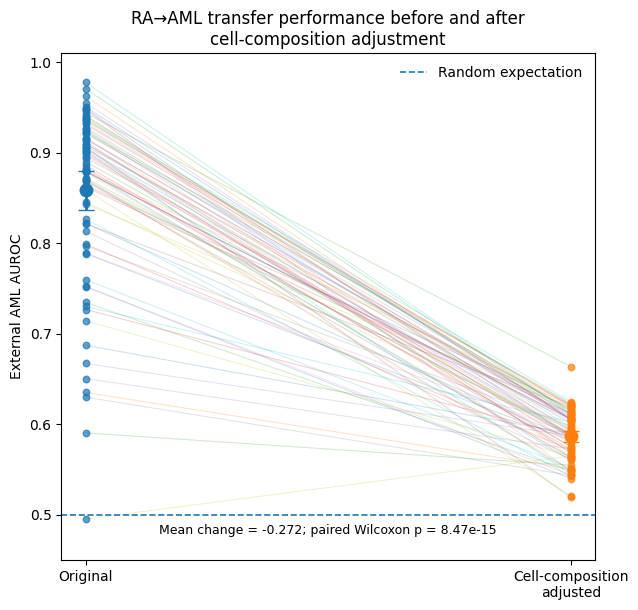

Saved: /content/drive/MyDrive/Deneme_2026/REVIEWER1_MAJOR3_EXACT_ORIGINAL_PROTOCOL/PUBLICATION_FIGURES/Figure_1B_AUROC_Distribution.png
Saved: /content/drive/MyDrive/Deneme_2026/REVIEWER1_MAJOR3_EXACT_ORIGINAL_PROTOCOL/PUBLICATION_FIGURES/Figure_1B_AUROC_Distribution.pdf


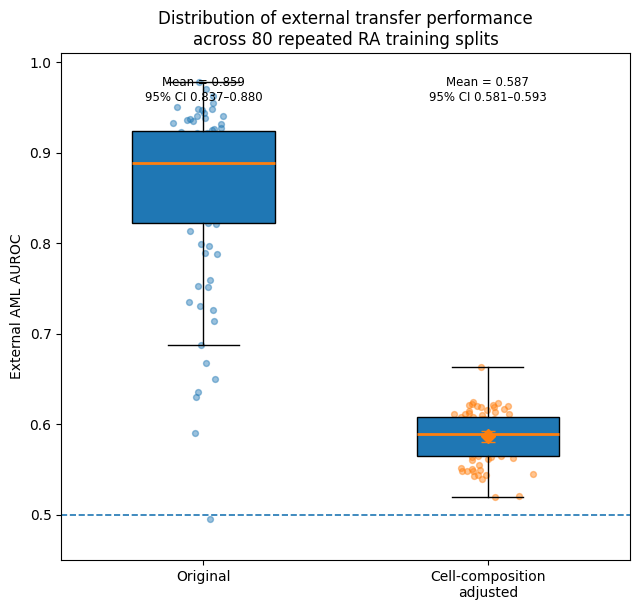

Saved: /content/drive/MyDrive/Deneme_2026/REVIEWER1_MAJOR3_EXACT_ORIGINAL_PROTOCOL/PUBLICATION_FIGURES/Figure_1C_Pathway_Cell_Association_Categories.png
Saved: /content/drive/MyDrive/Deneme_2026/REVIEWER1_MAJOR3_EXACT_ORIGINAL_PROTOCOL/PUBLICATION_FIGURES/Figure_1C_Pathway_Cell_Association_Categories.pdf


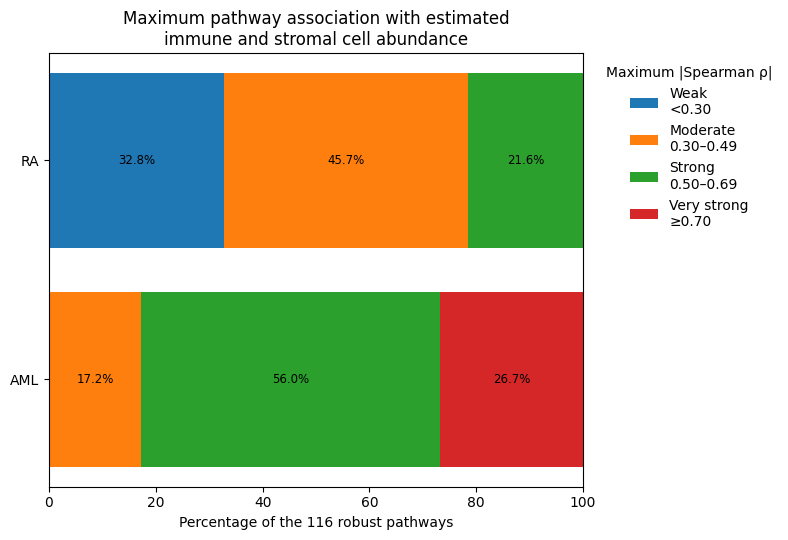

Saved: /content/drive/MyDrive/Deneme_2026/REVIEWER1_MAJOR3_EXACT_ORIGINAL_PROTOCOL/PUBLICATION_FIGURES/Supplementary_Figure_S1_Mean_ROC.png
Saved: /content/drive/MyDrive/Deneme_2026/REVIEWER1_MAJOR3_EXACT_ORIGINAL_PROTOCOL/PUBLICATION_FIGURES/Supplementary_Figure_S1_Mean_ROC.pdf


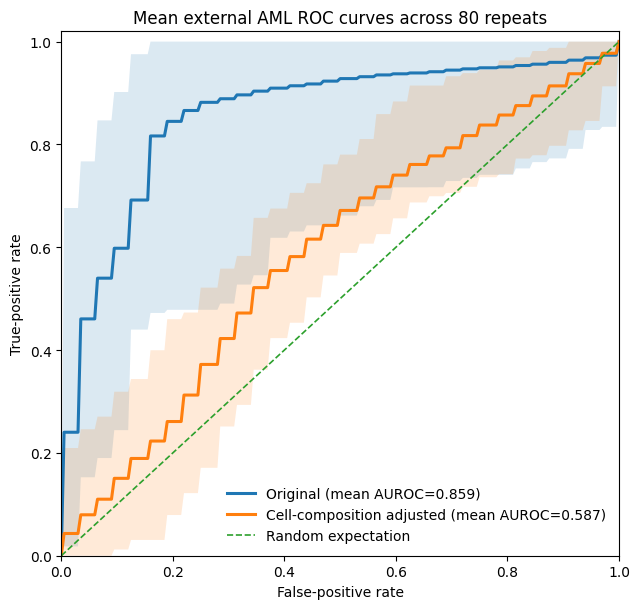

Saved: /content/drive/MyDrive/Deneme_2026/REVIEWER1_MAJOR3_EXACT_ORIGINAL_PROTOCOL/PUBLICATION_FIGURES/Supplementary_Figure_S2_Paired_PRAUC.png
Saved: /content/drive/MyDrive/Deneme_2026/REVIEWER1_MAJOR3_EXACT_ORIGINAL_PROTOCOL/PUBLICATION_FIGURES/Supplementary_Figure_S2_Paired_PRAUC.pdf


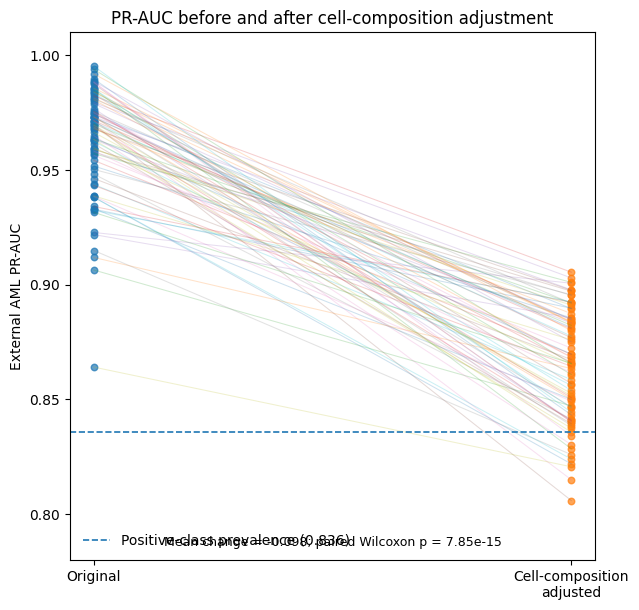

Saved: /content/drive/MyDrive/Deneme_2026/REVIEWER1_MAJOR3_EXACT_ORIGINAL_PROTOCOL/PUBLICATION_FIGURES/Supplementary_Figure_S3_RA_Correlation_Heatmap.png
Saved: /content/drive/MyDrive/Deneme_2026/REVIEWER1_MAJOR3_EXACT_ORIGINAL_PROTOCOL/PUBLICATION_FIGURES/Supplementary_Figure_S3_RA_Correlation_Heatmap.pdf


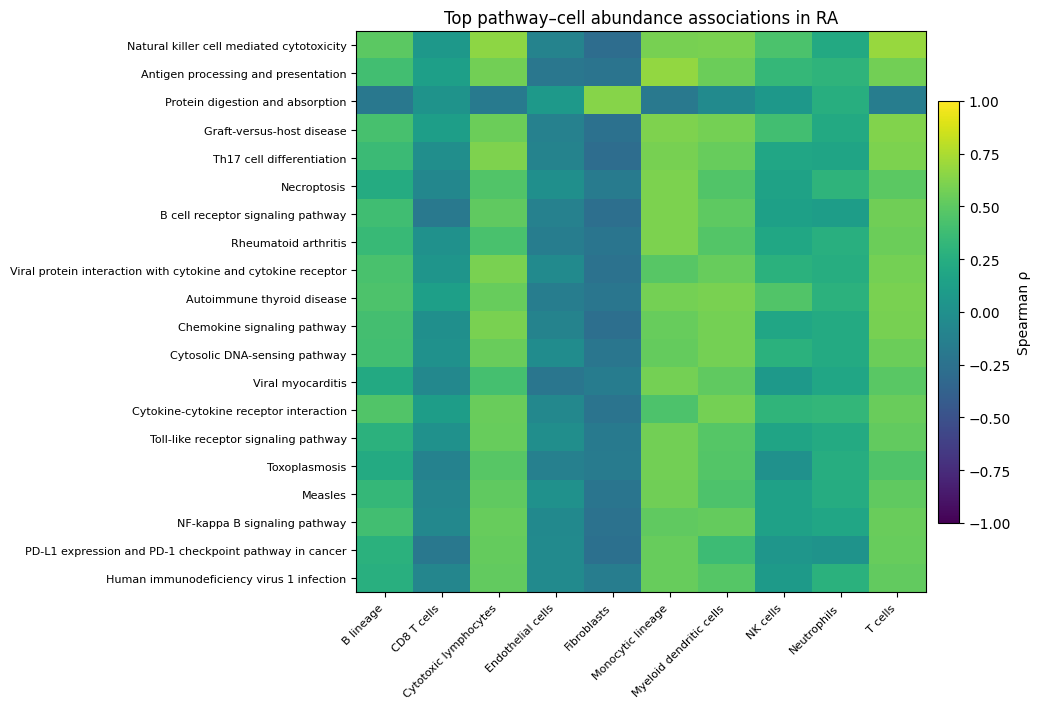

Saved: /content/drive/MyDrive/Deneme_2026/REVIEWER1_MAJOR3_EXACT_ORIGINAL_PROTOCOL/PUBLICATION_FIGURES/Supplementary_Figure_S3_AML_Correlation_Heatmap.png
Saved: /content/drive/MyDrive/Deneme_2026/REVIEWER1_MAJOR3_EXACT_ORIGINAL_PROTOCOL/PUBLICATION_FIGURES/Supplementary_Figure_S3_AML_Correlation_Heatmap.pdf


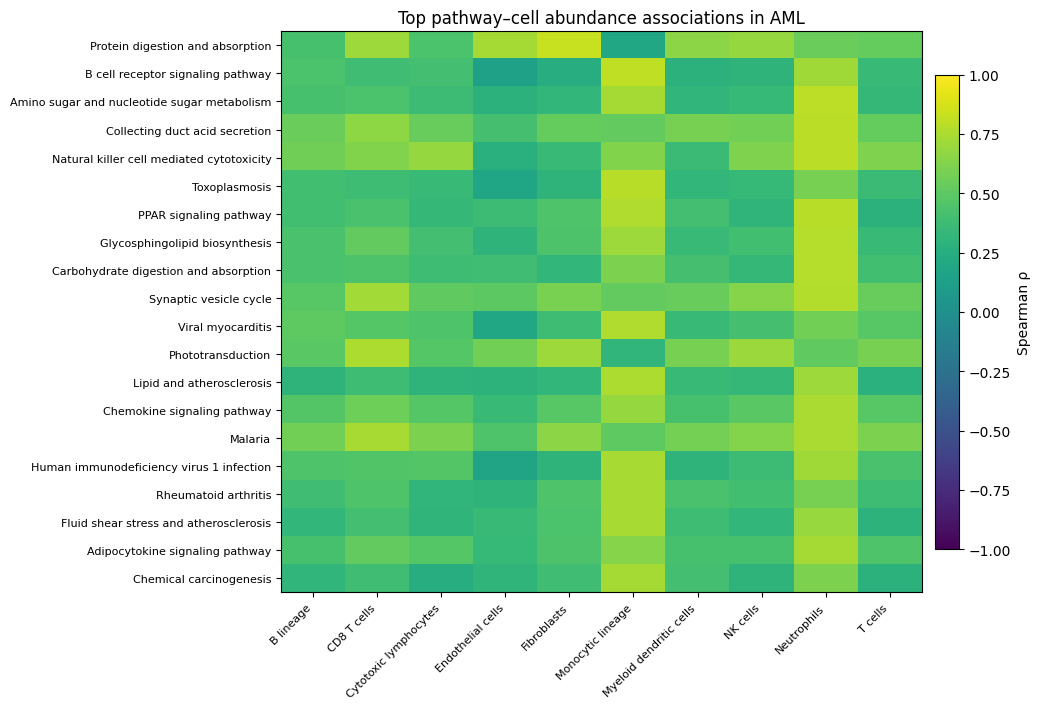


PUBLICATION FIGURES COMPLETED

Ana makaleye önerilenler:
1. Figure_1A_Paired_AUROC
2. Figure_1C_Pathway_Cell_Association_Categories

Ana figür iki panel olacaksa:
Panel A = paired AUROC
Panel B = pathway–cell association categories

Supplement için:
1. Figure_1B_AUROC_Distribution
2. Supplementary_Figure_S1_Mean_ROC
3. Supplementary_Figure_S2_Paired_PRAUC
4. Supplementary_Figure_S3_RA_Correlation_Heatmap
5. Supplementary_Figure_S3_AML_Correlation_Heatmap

Tüm dosyalar:
/content/drive/MyDrive/Deneme_2026/REVIEWER1_MAJOR3_EXACT_ORIGINAL_PROTOCOL/PUBLICATION_FIGURES

Figür istatistikleri:
/content/drive/MyDrive/Deneme_2026/REVIEWER1_MAJOR3_EXACT_ORIGINAL_PROTOCOL/PUBLICATION_FIGURES/Publication_Figure_Data_and_Statistics.xlsx


In [ ]:
# =============================================================================
# REVIEWER 1 – MAJOR COMMENT 3
# PUBLICATION-READY FIGURES
#
# Bu kod model eğitmez.
# Tamamlanan 80-run sonuç dosyasını okuyarak ana makale ve supplement için
# figürleri üretir.
# =============================================================================

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scipy.stats as st
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.metrics import roc_curve, roc_auc_score
from statsmodels.stats.multitest import multipletests

# -----------------------------------------------------------------------------
# 1. DOSYA YOLLARI
# -----------------------------------------------------------------------------

RESULT_DIR = Path(
    "/content/drive/MyDrive/Deneme_2026/"
    "REVIEWER1_MAJOR3_EXACT_ORIGINAL_PROTOCOL"
)

MASTER_FILE = (
    RESULT_DIR /
    "FINAL_Reviewer1_Major3_ExactOriginalProtocol.xlsx"
)

FIGURE_DIR = RESULT_DIR / "PUBLICATION_FIGURES"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

if not MASTER_FILE.exists():
    raise FileNotFoundError(
        f"Ana sonuç dosyası bulunamadı:\n{MASTER_FILE}"
    )

print("Ana dosya :", MASTER_FILE)
print("Figür yolu:", FIGURE_DIR)

# -----------------------------------------------------------------------------
# 2. DOSYALARI OKU
# -----------------------------------------------------------------------------

metrics = pd.read_excel(
    MASTER_FILE,
    sheet_name="PerRepeat_Metrics",
    engine="openpyxl"
)

predictions = pd.read_excel(
    MASTER_FILE,
    sheet_name="Target_Predictions",
    engine="openpyxl"
)

correlations = pd.read_excel(
    MASTER_FILE,
    sheet_name="Pathway_Cell_Correlations",
    engine="openpyxl"
)

original = (
    metrics.loc[
        metrics["Condition"] == "Original_expression"
    ]
    .sort_values("Repeat")
    .reset_index(drop=True)
)

residualized = (
    metrics.loc[
        metrics["Condition"] ==
        "Cell_residualized_expression"
    ]
    .sort_values("Repeat")
    .reset_index(drop=True)
)

if len(original) != 80 or len(residualized) != 80:
    raise ValueError(
        "Her koşul için 80 tekrar bekleniyordu. "
        f"Original={len(original)}, Residualized={len(residualized)}"
    )

print("\nMetrics:", metrics.shape)
print("Predictions:", predictions.shape)
print("Correlations:", correlations.shape)

# -----------------------------------------------------------------------------
# 3. YARDIMCI FONKSİYONLAR
# -----------------------------------------------------------------------------

def mean_ci(values, confidence=0.95):
    values = pd.Series(values).dropna().astype(float).values

    n = len(values)
    mean_value = np.mean(values)
    sd_value = np.std(values, ddof=1)
    sem_value = st.sem(values)

    critical = st.t.ppf(
        (1 + confidence) / 2,
        df=n - 1
    )

    margin = critical * sem_value

    return {
        "n": n,
        "mean": mean_value,
        "sd": sd_value,
        "median": np.median(values),
        "ci_low": mean_value - margin,
        "ci_high": mean_value + margin
    }


def bh_fdr(values):
    values = np.asarray(values, dtype=float)
    output = np.full(values.shape, np.nan)

    valid = np.isfinite(values)

    if valid.any():
        output[valid] = multipletests(
            values[valid],
            method="fdr_bh"
        )[1]

    return output


def save_figure(fig, filename):
    png_path = FIGURE_DIR / f"{filename}.png"
    pdf_path = FIGURE_DIR / f"{filename}.pdf"

    fig.savefig(
        png_path,
        dpi=600,
        bbox_inches="tight"
    )

    fig.savefig(
        pdf_path,
        bbox_inches="tight"
    )

    print("Saved:", png_path)
    print("Saved:", pdf_path)


def condition_label(value):
    mapping = {
        "Original_expression": "Original",
        "Cell_residualized_expression": "Cell-composition adjusted"
    }
    return mapping.get(value, value)


# =============================================================================
# FIGURE 1A
# PAIRED AUROC CHANGE
# Ana makaleye önerilen figür
# =============================================================================

original_auc = original["AUROC"].astype(float).values
residual_auc = residualized["AUROC"].astype(float).values

original_stats = mean_ci(original_auc)
residual_stats = mean_ci(residual_auc)

paired_test = st.wilcoxon(
    residual_auc,
    original_auc,
    zero_method="wilcox",
    alternative="two-sided"
)

fig, ax = plt.subplots(figsize=(6.5, 6.2))

for i in range(len(original_auc)):
    ax.plot(
        [0, 1],
        [original_auc[i], residual_auc[i]],
        linewidth=0.75,
        alpha=0.22
    )

ax.scatter(
    np.zeros(len(original_auc)),
    original_auc,
    s=22,
    alpha=0.70,
    zorder=3
)

ax.scatter(
    np.ones(len(residual_auc)),
    residual_auc,
    s=22,
    alpha=0.70,
    zorder=3
)

ax.errorbar(
    0,
    original_stats["mean"],
    yerr=[[
        original_stats["mean"] -
        original_stats["ci_low"]
    ], [
        original_stats["ci_high"] -
        original_stats["mean"]
    ]],
    fmt="o",
    markersize=9,
    capsize=6,
    linewidth=2.0,
    zorder=5
)

ax.errorbar(
    1,
    residual_stats["mean"],
    yerr=[[
        residual_stats["mean"] -
        residual_stats["ci_low"]
    ], [
        residual_stats["ci_high"] -
        residual_stats["mean"]
    ]],
    fmt="o",
    markersize=9,
    capsize=6,
    linewidth=2.0,
    zorder=5
)

ax.axhline(
    0.50,
    linestyle="--",
    linewidth=1.2,
    label="Random expectation"
)

ax.set_xticks([0, 1])
ax.set_xticklabels([
    "Original",
    "Cell-composition\nadjusted"
])

ax.set_ylabel("External AML AUROC")
ax.set_ylim(0.45, 1.01)

ax.set_title(
    "RA→AML transfer performance before and after\n"
    "cell-composition adjustment"
)

ax.text(
    0.5,
    0.475,
    (
        f"Mean change = "
        f"{np.mean(residual_auc-original_auc):.3f}; "
        f"paired Wilcoxon p = {paired_test.pvalue:.2e}"
    ),
    ha="center",
    va="bottom",
    fontsize=9
)

ax.legend(
    frameon=False,
    loc="upper right"
)

fig.tight_layout()

save_figure(
    fig,
    "Figure_1A_Paired_AUROC"
)

plt.show()

# =============================================================================
# FIGURE 1B
# AUROC DISTRIBUTION WITH MEAN AND 95% CI
# =============================================================================

fig, ax = plt.subplots(figsize=(6.5, 6.2))

positions = [1, 2]

box = ax.boxplot(
    [original_auc, residual_auc],
    positions=positions,
    widths=0.50,
    patch_artist=True,
    showfliers=False,
    medianprops={"linewidth": 2}
)

rng = np.random.default_rng(42)

for position, values in zip(
    positions,
    [original_auc, residual_auc]
):
    jitter = rng.normal(
        position,
        0.055,
        size=len(values)
    )

    ax.scatter(
        jitter,
        values,
        s=18,
        alpha=0.45
    )

ax.errorbar(
    1,
    original_stats["mean"],
    yerr=[[
        original_stats["mean"] -
        original_stats["ci_low"]
    ], [
        original_stats["ci_high"] -
        original_stats["mean"]
    ]],
    fmt="D",
    markersize=7,
    capsize=5,
    linewidth=1.8
)

ax.errorbar(
    2,
    residual_stats["mean"],
    yerr=[[
        residual_stats["mean"] -
        residual_stats["ci_low"]
    ], [
        residual_stats["ci_high"] -
        residual_stats["mean"]
    ]],
    fmt="D",
    markersize=7,
    capsize=5,
    linewidth=1.8
)

ax.axhline(
    0.50,
    linestyle="--",
    linewidth=1.2
)

ax.set_xticks(positions)
ax.set_xticklabels([
    "Original",
    "Cell-composition\nadjusted"
])

ax.set_ylabel("External AML AUROC")
ax.set_ylim(0.45, 1.01)

ax.set_title(
    "Distribution of external transfer performance\n"
    "across 80 repeated RA training splits"
)

ax.text(
    1,
    0.985,
    (
        f"Mean = {original_stats['mean']:.3f}\n"
        f"95% CI {original_stats['ci_low']:.3f}–"
        f"{original_stats['ci_high']:.3f}"
    ),
    ha="center",
    va="top",
    fontsize=8.5
)

ax.text(
    2,
    0.985,
    (
        f"Mean = {residual_stats['mean']:.3f}\n"
        f"95% CI {residual_stats['ci_low']:.3f}–"
        f"{residual_stats['ci_high']:.3f}"
    ),
    ha="center",
    va="top",
    fontsize=8.5
)

fig.tight_layout()

save_figure(
    fig,
    "Figure_1B_AUROC_Distribution"
)

plt.show()

# =============================================================================
# FIGURE 1C
# PATHWAY–CELL ASSOCIATION CATEGORIES
# Ana makale veya Supplement
# =============================================================================

correlations["Absolute_rho"] = (
    correlations["Spearman_rho"].abs()
)

if "FDR_within_domain" not in correlations.columns:
    correlations["FDR_within_domain"] = (
        correlations
        .groupby("Domain")["p_value"]
        .transform(
            lambda x: bh_fdr(x.values)
        )
    )

pathway_max = (
    correlations
    .groupby(
        ["Domain", "Pathway"],
        as_index=False
    )
    .agg(
        Maximum_absolute_rho=(
            "Absolute_rho",
            "max"
        ),
        Mean_absolute_rho=(
            "Absolute_rho",
            "mean"
        ),
        Minimum_FDR=(
            "FDR_within_domain",
            "min"
        )
    )
)

category_order = [
    "Weak\n<0.30",
    "Moderate\n0.30–0.49",
    "Strong\n0.50–0.69",
    "Very strong\n≥0.70"
]

pathway_max["Category"] = pd.cut(
    pathway_max["Maximum_absolute_rho"],
    bins=[
        -np.inf,
        0.30,
        0.50,
        0.70,
        np.inf
    ],
    labels=category_order,
    right=False
)

category_table = (
    pathway_max
    .groupby(
        ["Domain", "Category"],
        observed=False
    )
    .size()
    .unstack(fill_value=0)
    .reindex(
        columns=category_order
    )
)

category_percent = (
    category_table
    .div(category_table.sum(axis=1), axis=0)
    * 100
)

fig, ax = plt.subplots(figsize=(8.0, 5.5))

left = np.zeros(len(category_percent))

for category in category_order:
    values = category_percent[category].values

    bars = ax.barh(
        category_percent.index,
        values,
        left=left,
        label=category
    )

    for bar, value, start in zip(
        bars,
        values,
        left
    ):
        if value >= 7:
            ax.text(
                start + value / 2,
                bar.get_y() + bar.get_height() / 2,
                f"{value:.1f}%",
                ha="center",
                va="center",
                fontsize=8.5
            )

    left += values

ax.set_xlim(0, 100)
ax.set_xlabel(
    "Percentage of the 116 robust pathways"
)

ax.set_ylabel("")
ax.set_title(
    "Maximum pathway association with estimated\n"
    "immune and stromal cell abundance"
)

ax.legend(
    title="Maximum |Spearman ρ|",
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

fig.tight_layout()

save_figure(
    fig,
    "Figure_1C_Pathway_Cell_Association_Categories"
)

plt.show()

# =============================================================================
# SUPPLEMENTARY FIGURE S1
# MEAN ROC CURVES WITH 95% EMPIRICAL BANDS
# =============================================================================

fpr_grid = np.linspace(0, 1, 201)

fig, ax = plt.subplots(figsize=(6.5, 6.2))

roc_summary_rows = []

for condition in [
    "Original_expression",
    "Cell_residualized_expression"
]:
    subset = predictions.loc[
        predictions["Condition"] == condition
    ].copy()

    interpolated_tprs = []
    repeat_aucs = []

    for repeat in sorted(
        subset["Repeat"].unique()
    ):
        repeat_data = subset.loc[
            subset["Repeat"] == repeat
        ]

        y_true = repeat_data[
            "True_label"
        ].astype(int).values

        y_score = repeat_data[
            "Predicted_probability_AML"
        ].astype(float).values

        fpr, tpr, _ = roc_curve(
            y_true,
            y_score
        )

        interp_tpr = np.interp(
            fpr_grid,
            fpr,
            tpr
        )

        interp_tpr[0] = 0.0
        interp_tpr[-1] = 1.0

        interpolated_tprs.append(
            interp_tpr
        )

        repeat_aucs.append(
            roc_auc_score(
                y_true,
                y_score
            )
        )

    interpolated_tprs = np.asarray(
        interpolated_tprs
    )

    mean_tpr = interpolated_tprs.mean(axis=0)
    lower_tpr = np.percentile(
        interpolated_tprs,
        2.5,
        axis=0
    )
    upper_tpr = np.percentile(
        interpolated_tprs,
        97.5,
        axis=0
    )

    mean_auc = np.mean(repeat_aucs)

    ax.plot(
        fpr_grid,
        mean_tpr,
        linewidth=2.2,
        label=(
            f"{condition_label(condition)} "
            f"(mean AUROC={mean_auc:.3f})"
        )
    )

    ax.fill_between(
        fpr_grid,
        lower_tpr,
        upper_tpr,
        alpha=0.16
    )

    roc_summary_rows.append({
        "Condition": condition_label(condition),
        "Mean_AUROC": mean_auc,
        "SD_AUROC": np.std(
            repeat_aucs,
            ddof=1
        )
    })

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.2,
    label="Random expectation"
)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.set_xlabel("False-positive rate")
ax.set_ylabel("True-positive rate")

ax.set_title(
    "Mean external AML ROC curves across 80 repeats"
)

ax.legend(
    frameon=False,
    loc="lower right"
)

fig.tight_layout()

save_figure(
    fig,
    "Supplementary_Figure_S1_Mean_ROC"
)

plt.show()

roc_summary = pd.DataFrame(
    roc_summary_rows
)

# =============================================================================
# SUPPLEMENTARY FIGURE S2
# PR-AUC PAIRED COMPARISON
# =============================================================================

original_pr = original["PR_AUC"].astype(float).values
residual_pr = residualized["PR_AUC"].astype(float).values

pr_test = st.wilcoxon(
    residual_pr,
    original_pr,
    zero_method="wilcox",
    alternative="two-sided"
)

fig, ax = plt.subplots(figsize=(6.5, 6.2))

for i in range(len(original_pr)):
    ax.plot(
        [0, 1],
        [original_pr[i], residual_pr[i]],
        linewidth=0.75,
        alpha=0.22
    )

ax.scatter(
    np.zeros(len(original_pr)),
    original_pr,
    s=22,
    alpha=0.70
)

ax.scatter(
    np.ones(len(residual_pr)),
    residual_pr,
    s=22,
    alpha=0.70
)

ax.axhline(
    163 / 195,
    linestyle="--",
    linewidth=1.2,
    label=(
        "Positive-class prevalence "
        f"({163/195:.3f})"
    )
)

ax.set_xticks([0, 1])
ax.set_xticklabels([
    "Original",
    "Cell-composition\nadjusted"
])

ax.set_ylabel("External AML PR-AUC")
ax.set_ylim(0.78, 1.01)

ax.set_title(
    "PR-AUC before and after cell-composition adjustment"
)

ax.text(
    0.5,
    0.785,
    (
        f"Mean change = "
        f"{np.mean(residual_pr-original_pr):.3f}; "
        f"paired Wilcoxon p = {pr_test.pvalue:.2e}"
    ),
    ha="center",
    va="bottom",
    fontsize=9
)

ax.legend(
    frameon=False,
    loc="lower left"
)

fig.tight_layout()

save_figure(
    fig,
    "Supplementary_Figure_S2_Paired_PRAUC"
)

plt.show()

# =============================================================================
# SUPPLEMENTARY FIGURE S3
# TOP PATHWAY–CELL CORRELATION HEATMAPS
#
# Her domain için maksimum mutlak korelasyona sahip en güçlü 20 pathway.
# =============================================================================

for domain in ["RA", "AML"]:

    domain_cor = correlations.loc[
        correlations["Domain"] == domain
    ].copy()

    top_pathways = (
        domain_cor
        .groupby("Pathway")["Absolute_rho"]
        .max()
        .sort_values(
            ascending=False
        )
        .head(20)
        .index
        .tolist()
    )

    heatmap_matrix = (
        domain_cor.loc[
            domain_cor["Pathway"].isin(
                top_pathways
            )
        ]
        .pivot(
            index="Pathway",
            columns="Cell_population",
            values="Spearman_rho"
        )
        .loc[top_pathways]
    )

    fig_height = max(
        7,
        len(heatmap_matrix) * 0.36
    )

    fig, ax = plt.subplots(
        figsize=(10.5, fig_height)
    )

    image = ax.imshow(
        heatmap_matrix.values,
        aspect="auto",
        vmin=-1,
        vmax=1
    )

    ax.set_xticks(
        np.arange(
            heatmap_matrix.shape[1]
        )
    )

    ax.set_xticklabels(
        heatmap_matrix.columns,
        rotation=45,
        ha="right",
        fontsize=8
    )

    ax.set_yticks(
        np.arange(
            heatmap_matrix.shape[0]
        )
    )

    ax.set_yticklabels(
        heatmap_matrix.index,
        fontsize=8
    )

    ax.set_title(
        f"Top pathway–cell abundance associations in {domain}"
    )

    colorbar = fig.colorbar(
        image,
        ax=ax,
        fraction=0.035,
        pad=0.02
    )

    colorbar.set_label(
        "Spearman ρ"
    )

    fig.tight_layout()

    save_figure(
        fig,
        f"Supplementary_Figure_S3_{domain}_Correlation_Heatmap"
    )

    plt.show()

# =============================================================================
# SUPPLEMENTARY TABLES
# =============================================================================

pathway_summary = (
    pathway_max
    .sort_values(
        [
            "Domain",
            "Maximum_absolute_rho"
        ],
        ascending=[
            True,
            False
        ]
    )
)

top_associations = (
    correlations
    .sort_values(
        [
            "Domain",
            "Absolute_rho"
        ],
        ascending=[
            True,
            False
        ]
    )
    .groupby(
        "Domain",
        group_keys=False
    )
    .head(20)
)

figure_statistics = pd.DataFrame({
    "Statistic": [
        "Original mean AUROC",
        "Original AUROC 95% CI low",
        "Original AUROC 95% CI high",
        "Adjusted mean AUROC",
        "Adjusted AUROC 95% CI low",
        "Adjusted AUROC 95% CI high",
        "Mean paired AUROC change",
        "Paired AUROC Wilcoxon p",
        "Original mean PR-AUC",
        "Adjusted mean PR-AUC",
        "Mean paired PR-AUC change",
        "Paired PR-AUC Wilcoxon p",
        "Positive class prevalence"
    ],
    "Value": [
        original_stats["mean"],
        original_stats["ci_low"],
        original_stats["ci_high"],
        residual_stats["mean"],
        residual_stats["ci_low"],
        residual_stats["ci_high"],
        np.mean(
            residual_auc -
            original_auc
        ),
        paired_test.pvalue,
        np.mean(original_pr),
        np.mean(residual_pr),
        np.mean(
            residual_pr -
            original_pr
        ),
        pr_test.pvalue,
        163 / 195
    ]
})

OUTPUT_TABLE = (
    FIGURE_DIR /
    "Publication_Figure_Data_and_Statistics.xlsx"
)

with pd.ExcelWriter(
    OUTPUT_TABLE,
    engine="openpyxl"
) as writer:

    figure_statistics.to_excel(
        writer,
        sheet_name="Figure_Statistics",
        index=False
    )

    category_table.to_excel(
        writer,
        sheet_name="Correlation_Category_Counts"
    )

    category_percent.to_excel(
        writer,
        sheet_name="Correlation_Category_Percent"
    )

    pathway_summary.to_excel(
        writer,
        sheet_name="Pathway_Max_Correlations",
        index=False
    )

    top_associations.to_excel(
        writer,
        sheet_name="Top_Associations",
        index=False
    )

    roc_summary.to_excel(
        writer,
        sheet_name="ROC_Summary",
        index=False
    )

print("\n" + "=" * 90)
print("PUBLICATION FIGURES COMPLETED")
print("=" * 90)

print("\nAna makaleye önerilenler:")
print("1. Figure_1A_Paired_AUROC")
print("2. Figure_1C_Pathway_Cell_Association_Categories")

print("\nAna figür iki panel olacaksa:")
print("Panel A = paired AUROC")
print("Panel B = pathway–cell association categories")

print("\nSupplement için:")
print("1. Figure_1B_AUROC_Distribution")
print("2. Supplementary_Figure_S1_Mean_ROC")
print("3. Supplementary_Figure_S2_Paired_PRAUC")
print("4. Supplementary_Figure_S3_RA_Correlation_Heatmap")
print("5. Supplementary_Figure_S3_AML_Correlation_Heatmap")

print("\nTüm dosyalar:")
print(FIGURE_DIR)

print("\nFigür istatistikleri:")
print(OUTPUT_TABLE)

print("=" * 90)

REV2 --- CML


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
!pip install -q gseapy

In [ ]:
# ==============================================================================
# RA (SOURCE) -> CML (TARGET, MILE/GSE13159) | FREEZE & ADAPT
# TOP 116 ROBUST KEGG PATHWAYS | BONE MARROW TISSUE-MATCHED
# GOOGLE COLAB VERSION -- dosya yolları kullanıcının kendi Drive yapısına göre ayarlandı
# ==============================================================================

# ------------------------------------------------------------------
# HÜCRE 1) Google Drive'ı bağla + paket kurulumu
# ------------------------------------------------------------------
!pip install -q gseapy openpyxl

from pathlib import Path
from google.colab import drive

MOUNT_POINT = Path("/content/drive")
if not (MOUNT_POINT / "MyDrive").is_dir():
    drive.mount(str(MOUNT_POINT))

# ------------------------------------------------------------------
# HÜCRE 2) Kütüphaneleri import et
# ------------------------------------------------------------------
import os, sys, gc, random, warnings
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import pandas as pd
import scipy.stats as st
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
    confusion_matrix, accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score)
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.constraints import NonNeg
from tensorflow.keras.regularizers import l1
from tensorflow.keras.backend import clear_session
from tensorflow.keras.utils import set_random_seed
from gseapy import get_library

print("TensorFlow:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

# ------------------------------------------------------------------
# HÜCRE 3) AYARLAR (SETTINGS) -- kendi Drive klasör yapınıza göre
# ------------------------------------------------------------------
SEED = 42

BASE_DIR = Path("/content/drive/MyDrive/Deneme_2026")

RA_EXPR = BASE_DIR / "combat_corrected_by_gse.xlsx"
RA_PHENO = BASE_DIR / "pheno_raw.xlsx"

MILE_EXPR = Path("/content/drive/MyDrive/Losemi/GSE13159_gene_unique.xlsx")
MILE_FULL_PHENO = Path("/content/drive/MyDrive/Losemi/GSE13159_FULL_PHENOTYPE.xlsx")

TOP_PATH_FILE = Path("/content/drive/MyDrive/Ra/yolak_secim_frekansi.xlsx")

SAVE_PATH = BASE_DIR / "RA2CML_FREEZE_ADAPT_TOP116_FINAL80"
SAVE_PATH.mkdir(parents=True, exist_ok=True)

LIBRARY = "KEGG_2021_Human"
TOP_N = 116

# --- ILK ONCE KUCUK DEGERLE TEST EDIN, SONRA 80'E CIKARIN ---
REPEATS = 80          # <-- ilk denemede 3, doğrulandıktan sonra 80 yapın
N_SPLITS = 5
EPOCHS_RA = 400
BATCH_RA = 32
LR_RA = 0.001
EPOCHS_ADAPT = 200
BATCH_ADAPT = 32
LR_ADAPT = 1e-4
L1_VAL = 0.001
MIN_GENES = 1
RA_TEST_SIZE = 0.20

TARGET_DISEASE = "CML"

random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
set_random_seed(SEED); clear_session()

print("="*100)
print(f"RA -> {TARGET_DISEASE} (MILE) | FREEZE & ADAPT | TOP {TOP_N} | REPEATS={REPEATS}")
print("="*100)

# ------------------------------------------------------------------
# HÜCRE 4) YARDIMCI FONKSİYONLAR (HELPERS)
# ------------------------------------------------------------------
def pick_col(df, cands):
    lookup = {str(c).strip().lower(): c for c in df.columns}
    for c in cands:
        k = str(c).strip().lower()
        if k in lookup: return lookup[k]
    return None

def clean_expression(df):
    df.index = df.index.astype(str).str.strip()
    df.columns = df.columns.astype(str).str.strip()
    valid = (df.index != "") & (~df.index.str.upper().isin(["NA","NAN","NONE","---"]))
    df = df.loc[valid]
    df = df.apply(pd.to_numeric, errors="coerce")
    df = df.dropna(axis=0, how="all")
    if df.isna().any().any():
        df = df.T.fillna(df.median(axis=1)).T
    return df.groupby(level=0, sort=False).mean().astype(np.float32)

def read_expr_xlsx(path):
    raw = pd.read_excel(path, engine="openpyxl")
    gene_col = pick_col(raw, ["Gen_name","Gene","Genes","gene","gene_symbol","SYMBOL","X","Unnamed: 0"])
    if gene_col is None: gene_col = raw.columns[0]
    print(f"Reading {Path(path).name} | gene column={gene_col}")
    return clean_expression(raw.set_index(gene_col))

def parse_field(value, field):
    if pd.isna(value): return None
    parts = [b.strip() for b in str(value).replace(";", "|").split("|") if b.strip()]
    for p in parts:
        if p.lower().startswith(field.lower()) and ":" in p:
            return p.split(":", 1)[1].strip()
    return None

def map_main_label(cls):
    if cls is None or pd.isna(cls): return None
    c = str(cls).strip().upper()
    if c.startswith("AML"): return "AML"
    if c == "CLL": return "CLL"
    if c == "CML": return "CML"
    if c == "MDS": return "MDS"
    if "NON-LEUKEMIA" in c or "HEALTHY" in c or "NORMAL" in c: return "HE"
    if "ALL" in c: return "ALL"
    return "OTHER"

def gaussian_kernel(X1, X2=None, sigma=1.0):
    if X2 is None: X2 = X1
    d2 = euclidean_distances(X1, X2, squared=True)
    return np.exp(-d2/(2.0*sigma**2)).astype(np.float32)

def compute_sigma(X):
    d2 = euclidean_distances(X, X, squared=True)
    upper = d2[np.triu_indices(X.shape[0], k=1)]
    upper = upper[upper > 0]
    if upper.size == 0: return 1.0
    s = float(np.mean(np.sqrt(upper)))
    return s if np.isfinite(s) and s > 0 else 1.0

def build_kernel_mlp(n_support, n_paths, lr):
    inputs = [Input(shape=(n_support,), name=f"path_in_{i}") for i in range(n_paths)]
    bias_input = Input(shape=(1,), name="bias_input")
    shared = Dense(1, use_bias=False, activation=None, name="shared_projection")
    proj = [shared(inp) for inp in inputs]
    bias = Dense(1, use_bias=False, name="bias_weight")(bias_input)
    merged = Concatenate(name="merged")(proj + [bias])
    out = Dense(1, activation="sigmoid", use_bias=False,
                kernel_regularizer=l1(L1_VAL), kernel_constraint=NonNeg(),
                name="final_output")(merged)
    model = Model(inputs=inputs + [bias_input], outputs=out)
    model.compile(optimizer=Adam(learning_rate=lr), loss="binary_crossentropy")
    return model

def configure_target_adaptation(model):
    # eta (final_output) ve bias DONDURULUR; sadece shared_projection (w) adapte edilir
    for layer in model.layers:
        if layer.name == "shared_projection":
            layer.trainable = True
        elif layer.name in {"final_output", "bias_weight"}:
            layer.trainable = False
        else:
            layer.trainable = False
    model.compile(optimizer=Adam(learning_rate=LR_ADAPT), loss="binary_crossentropy")
    return model

def to_inputs(X):
    return [X[:, i, :] for i in range(X.shape[1])] + [np.ones((X.shape[0], 1), dtype=np.float32)]

def class_weights(y):
    classes = np.unique(y)
    w = compute_class_weight(class_weight="balanced", classes=classes, y=y)
    return {int(c): float(wt) for c, wt in zip(classes, w)}

def best_threshold_youden(y, p):
    fpr, tpr, thr = roc_curve(y, p)
    finite = np.isfinite(thr)
    fpr, tpr, thr = fpr[finite], tpr[finite], thr[finite]
    return float(thr[np.argmax(tpr - fpr)])

def compute_metrics(y, p, thr):
    yhat = (np.asarray(p) >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, yhat, labels=[0,1]).ravel()
    spec = tn/(tn+fp) if (tn+fp)>0 else np.nan
    return {
        "AUROC": float(roc_auc_score(y, p)) if len(np.unique(y))>1 else np.nan,
        "PR_AUC": float(average_precision_score(y, p)) if len(np.unique(y))>1 else np.nan,
        "Accuracy": float(accuracy_score(y, yhat)),
        "Balanced_Accuracy": float(balanced_accuracy_score(y, yhat)),
        "Precision": float(precision_score(y, yhat, zero_division=0)),
        "Recall": float(recall_score(y, yhat, zero_division=0)),
        "Specificity": float(spec),
        "F1": float(f1_score(y, yhat, zero_division=0)),
        "Threshold": float(thr),
    }

def ci95_t(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) < 2: return (np.nan, np.nan)
    mean = float(np.mean(values))
    sem = st.sem(values)
    tcrit = st.t.ppf(0.975, len(values)-1)
    return (float(mean - tcrit*sem), float(mean + tcrit*sem))

print("Helpers loaded.")

# ------------------------------------------------------------------
# HÜCRE 5) Girdi dosyalarını kontrol et
# ------------------------------------------------------------------
print("[INPUT CHECK]")
for label, path in {"RA expression":RA_EXPR, "RA phenotype":RA_PHENO,
                     "MILE expression":MILE_EXPR, "MILE phenotype":MILE_FULL_PHENO,
                     "Pathway file":TOP_PATH_FILE}.items():
    print(f"{label:20s}: {path.exists()} | {path}")
    if not path.exists():
        raise FileNotFoundError(
            f"{label} bulunamadi: {path}\n"
            "Dosyayi Google Drive'daki ilgili klasore yukledigineizden emin olun."
        )

# ------------------------------------------------------------------
# HÜCRE 6) RA (kaynak domain) verisini yükle
# ------------------------------------------------------------------
print("[1/7] LOADING RA")
expr_ra = read_expr_xlsx(RA_EXPR)
ph_ra = pd.read_excel(RA_PHENO, engine="openpyxl")
ra_sample_col = pick_col(ph_ra, ["sample","Sample","GSM"])
ra_group_col = pick_col(ph_ra, ["group_raw","group","label"])
if ra_sample_col is None or ra_group_col is None:
    raise KeyError(f"RA phenotype columns not found: {list(ph_ra.columns)}")

ph_ra[ra_sample_col] = ph_ra[ra_sample_col].astype(str).str.strip()
ph_ra[ra_group_col] = ph_ra[ra_group_col].astype(str).str.strip().str.upper()
ph_ra = ph_ra.loc[ph_ra[ra_group_col].isin(["RA","HE"])].copy()
ra_samples = [s for s in expr_ra.columns if s in set(ph_ra[ra_sample_col])]
expr_ra = expr_ra.loc[:, ra_samples]
ra_group = ph_ra.set_index(ra_sample_col).loc[ra_samples, ra_group_col]
y_ra_full = np.array([1 if x=="RA" else 0 for x in ra_group.values], dtype=int)
print(f"RA n={len(ra_samples)} | RA={int(np.sum(y_ra_full==1))} | HE={int(np.sum(y_ra_full==0))}")

# ------------------------------------------------------------------
# HÜCRE 7) MILE (GSE13159) verisini yükle
# ------------------------------------------------------------------
print("[2/7] LOADING MILE / GSE13159")
expr_mile = read_expr_xlsx(MILE_EXPR)
ph_mile = pd.read_excel(MILE_FULL_PHENO, engine="openpyxl")
mile_sample_col = pick_col(ph_mile, ["GSM","sample","Sample"])
char_col = pick_col(ph_mile, ["characteristics_ch1"])
if mile_sample_col is None or char_col is None:
    raise KeyError(f"MILE phenotype columns not found: {list(ph_mile.columns)}")

ph_mile[mile_sample_col] = ph_mile[mile_sample_col].astype(str).str.strip()
ph_mile["sample_type"] = ph_mile[char_col].apply(lambda x: parse_field(x, "sample type"))
ph_mile["leukemia_class"] = ph_mile[char_col].apply(lambda x: parse_field(x, "leukemia class"))
ph_mile["main_label"] = ph_mile["leukemia_class"].apply(map_main_label)
ph_mile["sample_type_norm"] = ph_mile["sample_type"].astype(str).str.strip().str.lower()
avail = set(expr_mile.columns)
ph_mile = ph_mile.loc[ph_mile[mile_sample_col].isin(avail)].copy()

print("\nMILE label x sample type:")
print(pd.crosstab(ph_mile["main_label"], ph_mile["sample_type_norm"]))

cml_subtypes = ph_mile.loc[ph_mile["main_label"]=="CML", "leukemia_class"].value_counts()
print("\nCML leukemia_class breakdown:")
print(cml_subtypes)

# ------------------------------------------------------------------
# HÜCRE 8) CML kemik iliği hedef kohortunu oluştur
# ------------------------------------------------------------------
print(f"[3/7] BUILDING {TARGET_DISEASE} BONE-MARROW TARGET (MILE cohort)")
is_bm = ph_mile["sample_type_norm"].str.contains("bone marrow", na=False)
he_bm = ph_mile.loc[(ph_mile["main_label"]=="HE") & is_bm, mile_sample_col].tolist()
case_bm = ph_mile.loc[(ph_mile["main_label"]==TARGET_DISEASE) & is_bm, mile_sample_col].tolist()
print(f"{TARGET_DISEASE} bone marrow = {len(case_bm)} | Healthy bone marrow = {len(he_bm)}")
if len(case_bm) == 0 or len(he_bm) == 0:
    raise ValueError(f"No valid {TARGET_DISEASE}/healthy bone-marrow target set found.")

target_samples_all = he_bm + case_bm
y_target_all = np.array([0]*len(he_bm) + [1]*len(case_bm), dtype=int)
print("Target total:", len(target_samples_all), "| CML prevalence:", round(float(np.mean(y_target_all)),4))

print("\nNOTE: CML n's are typically small in MILE (~76 CML cases).")
print("With N_SPLITS=5, each test fold will have very few CML positives --")
print("expect wider confidence intervals than for AML. This is expected, not a bug.")

# ------------------------------------------------------------------
# HÜCRE 9) Ortak genleri belirle
# ------------------------------------------------------------------
print("[4/7] COMMON GENES")
common_genes = sorted(set(expr_ra.index) & set(expr_mile.index))
expr_ra_c = expr_ra.loc[common_genes]
expr_mile_c = expr_mile.loc[common_genes]
print("Common genes:", len(common_genes))

# ------------------------------------------------------------------
# HÜCRE 10) Top 116 robust KEGG pathway listesini yükle
# ------------------------------------------------------------------
print("[5/7] LOADING TOP 116 ROBUST KEGG PATHWAYS")
freq = pd.read_excel(TOP_PATH_FILE, engine="openpyxl")
pcol = pick_col(freq, ["Pathway"]); ccol = pick_col(freq, ["Selection_Count","Count"])
if pcol is None or ccol is None:
    raise KeyError(f"Pathway-frequency columns not found: {list(freq.columns)}")
top_paths = freq.sort_values(ccol, ascending=False).head(TOP_N)[pcol].astype(str).str.strip().tolist()
kegg = get_library(name=LIBRARY, organism="Human")
active_paths = []
for p in top_paths:
    if p in kegg:
        genes = sorted(set(kegg[p]) & set(common_genes))
        if len(genes) >= MIN_GENES:
            active_paths.append((p, genes))
print(f"Requested Top {TOP_N} -> usable pathways = {len(active_paths)}")
if len(active_paths) == 0:
    raise ValueError("No pathways could be mapped.")

pd.DataFrame({
    "Pathway": [p for p, _ in active_paths],
    "Common_gene_count": [len(g) for _, g in active_paths],
}).to_excel(SAVE_PATH / "Active_Top116_Pathways.xlsx", index=False)
print("Active pathways saved.")

# ------------------------------------------------------------------
# HÜCRE 11) ANA DÖNGÜ: RA'da eğit -> CML'de Freeze & Adapt (5-fold CV x REPEATS)
# Not: En uzun süren kısım budur. REPEATS=3 ile test edip sorun yoksa
# HÜCRE 3'e dönüp REPEATS = 80 yapıp bu hücreyi tekrar çalıştırın.
# Runtime > Change runtime type > GPU seçmeyi unutmayın.
# ------------------------------------------------------------------
print(f"[6/7] TRAINING RA -> FREEZE & ADAPT ON {TARGET_DISEASE} "
      f"({REPEATS} repeats x {N_SPLITS} folds)")

all_rows = []
prediction_rows = []

for rep in range(REPEATS):
    rep_number = rep + 1
    split_seed = SEED + rep

    tr_idx, _ = train_test_split(
        np.arange(len(ra_samples)), test_size=RA_TEST_SIZE,
        stratify=y_ra_full, random_state=split_seed
    )
    source_samples = np.asarray(ra_samples)[tr_idx].tolist()
    y_source = y_ra_full[tr_idx]

    ra_scaler = StandardScaler().fit(expr_ra_c[source_samples].T)
    ra_scaled = pd.DataFrame(
        ra_scaler.transform(expr_ra_c[source_samples].T).T,
        index=common_genes, columns=source_samples
    )

    Ktr_list, pathway_sigmas = [], {}
    for pathway, genes in active_paths:
        mat_tr = ra_scaled.loc[genes, source_samples].T.values
        sigma = compute_sigma(mat_tr)
        pathway_sigmas[pathway] = sigma
        Ktr_list.append(gaussian_kernel(mat_tr, sigma=sigma))
    Xtr = np.transpose(np.stack(Ktr_list), (1,0,2)).astype(np.float32)

    clear_session(); set_random_seed(split_seed)
    source_model = build_kernel_mlp(Xtr.shape[2], Xtr.shape[1], LR_RA)
    source_model.fit(to_inputs(Xtr), y_source, epochs=EPOCHS_RA, batch_size=BATCH_RA,
                      verbose=0, class_weight=class_weights(y_source), shuffle=True)
    source_weights = source_model.get_weights()

    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=split_seed + 29)

    for fold_idx, (train_idx, test_idx) in enumerate(
        cv.split(target_samples_all, y_target_all), start=1
    ):
        target_train = np.asarray(target_samples_all)[train_idx].tolist()
        target_test = np.asarray(target_samples_all)[test_idx].tolist()
        y_train_t = y_target_all[train_idx]
        y_test_t = y_target_all[test_idx]

        mile_train_scaler = StandardScaler().fit(expr_mile_c[target_train].T)
        mile_train_scaled = pd.DataFrame(
            mile_train_scaler.transform(expr_mile_c[target_train].T).T,
            index=common_genes, columns=target_train
        )
        mile_test_scaled = pd.DataFrame(
            mile_train_scaler.transform(expr_mile_c[target_test].T).T,
            index=common_genes, columns=target_test
        )

        Ktrain_list, Ktest_list = [], []
        for pathway, genes in active_paths:
            sigma = pathway_sigmas[pathway]
            source_matrix = ra_scaled.loc[genes, source_samples].T.values
            train_matrix = mile_train_scaled.loc[genes, target_train].T.values
            test_matrix = mile_test_scaled.loc[genes, target_test].T.values
            Ktrain_list.append(gaussian_kernel(train_matrix, source_matrix, sigma=sigma))
            Ktest_list.append(gaussian_kernel(test_matrix, source_matrix, sigma=sigma))

        Xtrain_t = np.transpose(np.stack(Ktrain_list), (1,0,2)).astype(np.float32)
        Xtest_t = np.transpose(np.stack(Ktest_list), (1,0,2)).astype(np.float32)

        clear_session()
        adapt_seed = split_seed*1000 + fold_idx
        set_random_seed(adapt_seed)

        target_model = build_kernel_mlp(Xtr.shape[2], Xtr.shape[1], LR_RA)
        target_model.set_weights(source_weights)
        target_model = configure_target_adaptation(target_model)
        target_model.fit(to_inputs(Xtrain_t), y_train_t, epochs=EPOCHS_ADAPT,
                          batch_size=BATCH_ADAPT, verbose=0,
                          class_weight=class_weights(y_train_t), shuffle=True)

        p_train = target_model.predict(to_inputs(Xtrain_t), verbose=0).flatten()
        thr = best_threshold_youden(y_train_t, p_train)  # Youden J, sadece TRAIN fold

        p_test = target_model.predict(to_inputs(Xtest_t), verbose=0).flatten()
        met = compute_metrics(y_test_t, p_test, thr)
        met.update({"Disease": TARGET_DISEASE, "Repeat": rep_number, "Fold": fold_idx})
        all_rows.append(met)

        for s, y, p in zip(target_test, y_test_t, p_test):
            prediction_rows.append({
                "Repeat": rep_number, "Fold": fold_idx, "Sample": s,
                "True_label": int(y), "Predicted_probability": float(p)
            })

        del target_model, Xtrain_t, Xtest_t
        clear_session(); gc.collect()

    recent = pd.DataFrame(all_rows)
    print(f"  ... repeat {rep_number}/{REPEATS} done | "
          f"running mean AUROC so far = {recent['AUROC'].mean():.4f}")

    del source_model, Xtr
    clear_session(); gc.collect()

metrics_df = pd.DataFrame(all_rows)
predictions_df = pd.DataFrame(prediction_rows)
print("\nLoop finished.")

# ------------------------------------------------------------------
# HÜCRE 12) Özet istatistikler + Google Drive'a kaydet
# ------------------------------------------------------------------
print("[7/7] SUMMARY")
repeat_means = metrics_df.groupby("Repeat")[["AUROC","PR_AUC","Accuracy","Balanced_Accuracy",
                                              "Precision","Recall","Specificity","F1"]].mean()

summary_rows = []
for metric in ["AUROC","PR_AUC","Accuracy","Balanced_Accuracy","Precision","Recall","Specificity","F1"]:
    values = repeat_means[metric].values
    low, high = ci95_t(values)
    summary_rows.append({
        "Metric": metric, "N_repeats": len(values),
        "Mean": float(np.mean(values)), "SD": float(np.std(values, ddof=1)) if len(values)>1 else np.nan,
        "Median": float(np.median(values)), "Min": float(np.min(values)), "Max": float(np.max(values)),
        "CI95_low": low, "CI95_high": high,
    })
summary_df = pd.DataFrame(summary_rows)

auroc_values = repeat_means["AUROC"].values
try:
    wilcoxon_stat, wilcoxon_p = st.wilcoxon(auroc_values - 0.5, alternative="greater")
except Exception:
    wilcoxon_stat, wilcoxon_p = np.nan, np.nan

print("\nSUMMARY (mean across repeats, 95% CI):")
print(summary_df.round(4).to_string(index=False))
print(f"\nOne-sided Wilcoxon test (AUROC > 0.50): statistic={wilcoxon_stat}, p={wilcoxon_p:.6g}")

out_xlsx = SAVE_PATH / f"RA2{TARGET_DISEASE}_MILE_FreezeAdapt_Top116_{REPEATS}reps.xlsx"
with pd.ExcelWriter(out_xlsx, engine="openpyxl") as writer:
    metrics_df.to_excel(writer, sheet_name="Fold_Metrics", index=False)
    repeat_means.to_excel(writer, sheet_name="Repeat_Means")
    summary_df.to_excel(writer, sheet_name="Summary", index=False)
    pd.DataFrame({
        "Test": ["AUROC vs 0.50 (one-sided Wilcoxon)"],
        "Statistic": [wilcoxon_stat], "P_value": [wilcoxon_p],
        "N_repeats": [len(auroc_values)],
    }).to_excel(writer, sheet_name="Chance_Test", index=False)
    predictions_df.to_excel(writer, sheet_name="Predictions", index=False)
    cml_subtypes.reset_index().to_excel(writer, sheet_name="CML_Subtype_Check", index=False)

print("\nSaved to Google Drive:", out_xlsx)
print("="*100)
print("DONE.")
print("="*100)

TensorFlow: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
RA -> CML (MILE) | FREEZE & ADAPT | TOP 116 | REPEATS=80
Helpers loaded.
[INPUT CHECK]
RA expression       : True | /content/drive/MyDrive/Deneme_2026/combat_corrected_by_gse.xlsx
RA phenotype        : True | /content/drive/MyDrive/Deneme_2026/pheno_raw.xlsx
MILE expression     : True | /content/drive/MyDrive/Losemi/GSE13159_gene_unique.xlsx
MILE phenotype      : True | /content/drive/MyDrive/Losemi/GSE13159_FULL_PHENOTYPE.xlsx
Pathway file        : True | /content/drive/MyDrive/Ra/yolak_secim_frekansi.xlsx
[1/7] LOADING RA
Reading combat_corrected_by_gse.xlsx | gene column=Gen_name
RA n=195 | RA=163 | HE=32
[2/7] LOADING MILE / GSE13159
Reading GSE13159_gene_unique.xlsx | gene column=gene

MILE label x sample type:
sample_type_norm  bone marrow  peripheral blood
main_label                                     
ALL                       710                40
AML                       501

  ... repeat 1/80 done | running mean AUROC so far = 0.6440
  ... repeat 2/80 done | running mean AUROC so far = 0.6640
  ... repeat 3/80 done | running mean AUROC so far = 0.6340
  ... repeat 4/80 done | running mean AUROC so far = 0.6482
  ... repeat 5/80 done | running mean AUROC so far = 0.6637
  ... repeat 6/80 done | running mean AUROC so far = 0.6909
  ... repeat 7/80 done | running mean AUROC so far = 0.6849
  ... repeat 8/80 done | running mean AUROC so far = 0.6842
  ... repeat 9/80 done | running mean AUROC so far = 0.6718
  ... repeat 10/80 done | running mean AUROC so far = 0.6661
  ... repeat 11/80 done | running mean AUROC so far = 0.6613
  ... repeat 12/80 done | running mean AUROC so far = 0.6598
  ... repeat 13/80 done | running mean AUROC so far = 0.6672
  ... repeat 14/80 done | running mean AUROC so far = 0.6566
  ... repeat 15/80 done | running mean AUROC so far = 0.6567
  ... repeat 16/80 done | running mean AUROC so far = 0.6559
  ... repeat 17/80 done | running

In [ ]:
# =============================================================================
# FIND SAVED AML / PROSTATE RESULTS IN GOOGLE DRIVE
# + CALCULATE MISSING TABLE-4 METRICS WITHOUT RERUNNING 80 MODELS
# =============================================================================

from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import pandas as pd
import numpy as np
import os

ROOT = Path("/content/drive/MyDrive")
DENEME = ROOT / "Deneme_2026"

print("=" * 120)
print("SEARCHING SAVED RESULTS")
print("=" * 120)

# -----------------------------------------------------------------------------
# 1. FIND ALL RELEVANT RESULT FILES
# -----------------------------------------------------------------------------

keywords = [
    "FINAL_RA2LEUK_FIXED116",
    "LEUK_External_PerRepeat",
    "PROSTATE",
    "RA2PROSTATE",
    "GSE62872",
]

candidates = []

for p in DENEME.rglob("*"):
    if not p.is_file():
        continue

    name_upper = str(p).upper()

    if (
        any(k.upper() in name_upper for k in keywords)
        and p.suffix.lower() in [".xlsx", ".csv"]
    ):
        candidates.append(p)

print(f"\nFound {len(candidates)} candidate files:\n")

for i, p in enumerate(candidates, 1):
    print(f"{i:3d}. {p}")


# =============================================================================
# 2. HELPER FUNCTIONS
# =============================================================================

def read_table(path):
    if path.suffix.lower() == ".xlsx":
        return pd.read_excel(path, engine="openpyxl")
    else:
        return pd.read_csv(path)


def standardize_colnames(df):
    out = df.copy()

    mapping = {}

    for c in out.columns:
        x = str(c).strip().lower().replace(" ", "_").replace("-", "_")

        if x in ["auc", "auroc", "roc_auc"]:
            mapping[c] = "AUROC"

        elif x in ["pr_auc", "prauc", "average_precision"]:
            mapping[c] = "PR_AUC"

        elif x in ["accuracy", "acc"]:
            mapping[c] = "Accuracy"

        elif x in ["precision", "prec"]:
            mapping[c] = "Precision"

        elif x in ["recall", "sensitivity", "sens", "tpr"]:
            mapping[c] = "Recall"

        elif x in ["specificity", "spec", "tnr"]:
            mapping[c] = "Specificity"

        elif x in ["balanced_accuracy", "balanced_acc", "balacc"]:
            mapping[c] = "Balanced_Accuracy"

        elif x in ["f1", "f1_score"]:
            mapping[c] = "F1"

        elif x == "tn":
            mapping[c] = "TN"

        elif x == "fp":
            mapping[c] = "FP"

        elif x == "fn":
            mapping[c] = "FN"

        elif x == "tp":
            mapping[c] = "TP"

        elif x in ["repeat", "rep"]:
            mapping[c] = "Repeat"

    return out.rename(columns=mapping)


def add_confusion_metrics(df):
    """
    Calculates Specificity and Balanced Accuracy directly from
    TN/FP/FN/TP when available.
    """
    df = standardize_colnames(df)

    if {"TN", "FP"}.issubset(df.columns):
        denom = df["TN"] + df["FP"]

        df["Specificity"] = np.where(
            denom > 0,
            df["TN"] / denom,
            np.nan
        )

    if "Recall" not in df.columns and {"TP", "FN"}.issubset(df.columns):
        denom = df["TP"] + df["FN"]

        df["Recall"] = np.where(
            denom > 0,
            df["TP"] / denom,
            np.nan
        )

    if {"Recall", "Specificity"}.issubset(df.columns):
        df["Balanced_Accuracy"] = (
            df["Recall"] + df["Specificity"]
        ) / 2

    return df


def summarize_metric(x):
    x = pd.to_numeric(x, errors="coerce").dropna()

    n = len(x)

    if n == 0:
        return [np.nan, np.nan, np.nan, 0]

    mean = x.mean()

    # 95% CI for mean across repetitions
    if n > 1:
        se = x.std(ddof=1) / np.sqrt(n)
        lo = mean - 1.96 * se
        hi = mean + 1.96 * se
    else:
        lo = hi = mean

    return [mean, lo, hi, n]


def make_summary(df, cohort_name):
    df = add_confusion_metrics(df)

    metrics = [
        "AUROC",
        "PR_AUC",
        "Accuracy",
        "Balanced_Accuracy",
        "Precision",
        "Recall",
        "Specificity",
        "F1",
    ]

    rows = []

    for metric in metrics:

        if metric in df.columns:
            mean, lo, hi, n = summarize_metric(df[metric])

            rows.append({
                "Cohort": cohort_name,
                "Metric": metric,
                "Mean": mean,
                "CI95_low": lo,
                "CI95_high": hi,
                "N_repeats": n,
            })

        else:
            rows.append({
                "Cohort": cohort_name,
                "Metric": metric,
                "Mean": np.nan,
                "CI95_low": np.nan,
                "CI95_high": np.nan,
                "N_repeats": 0,
            })

    return pd.DataFrame(rows), df


# =============================================================================
# 3. LOAD GSE15061 AML 116-PATHWAY SAVED RESULTS
# =============================================================================

print("\n" + "=" * 120)
print("GSE15061 AML | TOP 116")
print("=" * 120)

AML_DIR = DENEME / "FINAL_RA2LEUK_FIXED116"

aml_options = [
    AML_DIR / "LEUK_External_PerRepeat_Metrics_FIXED.xlsx",
    AML_DIR / "LEUK_External_PerRepeat_Metrics.xlsx",
]

AML_FILE = None

for f in aml_options:
    if f.exists():
        AML_FILE = f
        break

if AML_FILE is None:
    found = list(AML_DIR.glob("*PerRepeat*.xlsx"))

    if found:
        AML_FILE = found[0]

if AML_FILE is None:
    print("AML per-repeat file NOT FOUND in expected directory.")
else:
    print("AML file:")
    print(AML_FILE)

    aml_raw = read_table(AML_FILE)

    print("\nColumns:")
    print(list(aml_raw.columns))

    aml_summary, aml_metrics = make_summary(
        aml_raw,
        "GSE15061 AML"
    )

    print("\nAML SUMMARY")
    print(
        aml_summary.to_string(
            index=False,
            float_format=lambda x: f"{x:.4f}"
        )
    )


# =============================================================================
# 4. AUTOMATICALLY FIND 116-PATHWAY PROSTATE RESULTS
# =============================================================================

print("\n" + "=" * 120)
print("SEARCHING GSE62872 / PROSTATE | TOP 116")
print("=" * 120)

pros_files = []

for p in DENEME.rglob("*"):
    if not p.is_file():
        continue

    full = str(p).upper()

    if (
        ("PROSTATE" in full or "GSE62872" in full)
        and "PERREPEAT" in full
        and p.suffix.lower() in [".xlsx", ".csv"]
    ):
        pros_files.append(p)

print(f"Possible prostate per-repeat files: {len(pros_files)}")

for i, f in enumerate(pros_files, 1):
    print(f"{i:2d}. {f}")


# Try to prioritize a folder/file containing 116
PROS_FILE = None

for f in pros_files:
    if "116" in str(f):
        PROS_FILE = f
        break

# If no filename contains 116, inspect all candidates
if PROS_FILE is None and pros_files:
    print("\nNo prostate filename explicitly contains '116'.")
    print("Inspecting candidate files for mean AUROC close to the known 116-pathway result (~0.4337)...")

    scored = []

    for f in pros_files:
        try:
            df = add_confusion_metrics(read_table(f))

            if "AUROC" in df.columns:
                auc = pd.to_numeric(
                    df["AUROC"],
                    errors="coerce"
                ).mean()

                scored.append((f, auc))

        except Exception as e:
            pass

    scored = sorted(
        scored,
        key=lambda z: abs(z[1] - 0.4337)
    )

    print("\nCandidate files ranked by closeness to AUROC=0.4337:")

    for f, auc in scored[:10]:
        print(f"{auc:.4f} | {f}")

    if scored:
        PROS_FILE = scored[0][0]


# =============================================================================
# 5. SUMMARIZE PROSTATE
# =============================================================================

if PROS_FILE is None:

    print("\nNo usable prostate per-repeat file found.")

else:

    print("\nSelected prostate file:")
    print(PROS_FILE)

    pros_raw = read_table(PROS_FILE)

    print("\nColumns:")
    print(list(pros_raw.columns))

    pros_summary, pros_metrics = make_summary(
        pros_raw,
        "GSE62872 PCa"
    )

    print("\nPROSTATE SUMMARY")

    print(
        pros_summary.to_string(
            index=False,
            float_format=lambda x: f"{x:.4f}"
        )
    )


# =============================================================================
# 6. FINAL TABLE-4 MISSING METRICS
# =============================================================================

print("\n" + "=" * 120)
print("TABLE 4 — VALUES RECOVERED FROM SAVED FILES")
print("=" * 120)

all_summaries = []

if AML_FILE is not None:
    all_summaries.append(aml_summary)

if PROS_FILE is not None:
    all_summaries.append(pros_summary)

if all_summaries:

    final_summary = pd.concat(
        all_summaries,
        ignore_index=True
    )

    print(
        final_summary[
            [
                "Cohort",
                "Metric",
                "Mean",
                "CI95_low",
                "CI95_high",
                "N_repeats"
            ]
        ].to_string(
            index=False,
            float_format=lambda x: f"{x:.4f}"
        )
    )

    OUT = DENEME / "TABLE4_RECOVERED_MISSING_METRICS.xlsx"

    with pd.ExcelWriter(
        OUT,
        engine="openpyxl"
    ) as writer:

        final_summary.to_excel(
            writer,
            sheet_name="Summary",
            index=False
        )

        if AML_FILE is not None:
            aml_metrics.to_excel(
                writer,
                sheet_name="GSE15061_AML_PerRepeat",
                index=False
            )

        if PROS_FILE is not None:
            pros_metrics.to_excel(
                writer,
                sheet_name="GSE62872_PCa_PerRepeat",
                index=False
            )

    print("\nSAVED:")
    print(OUT)

print("\nDONE.")

Mounted at /content/drive
SEARCHING SAVED RESULTS

Found 19 candidate files:

  1. /content/drive/MyDrive/Deneme_2026/FINAL_RA2LEUK_FIXED/LEUK_External_PerRepeat_Metrics_FIXED.xlsx
  2. /content/drive/MyDrive/Deneme_2026/FINAL_RA2LEUK_FIXED/LEUK_External_PerRepeat_Metrics.xlsx
  3. /content/drive/MyDrive/Deneme_2026/FINAL_RA2LEUK_FIXED116/LEUK_External_PerRepeat_Metrics_FIXED.xlsx
  4. /content/drive/MyDrive/Deneme_2026/FINAL_RA2LEUK_FIXED116/LEUK_External_PerRepeat_Metrics.xlsx
  5. /content/drive/MyDrive/Deneme_2026/FINAL_RA2LEUK_FIXED116/RA_Internal_PerRepeat_Metrics.xlsx
  6. /content/drive/MyDrive/Deneme_2026/FINAL_RA2LEUK_FIXED116/L1_CV_Scores_RA_only.xlsx
  7. /content/drive/MyDrive/Deneme_2026/FINAL_RA2LEUK_FIXED116/Pathway_Selection_Frequency.xlsx
  8. /content/drive/MyDrive/Deneme_2026/FINAL_RA2LEUK_FIXED116/SUMMARY_MeanStd_RA_and_LEUK.xlsx
  9. /content/drive/MyDrive/Deneme_2026/FINAL_RA2LEUK_FIXED_WADAPT/LEUK_External_PerRepeat_Metrics.xlsx
 10. /content/drive/MyDrive/Denem

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import pandas as pd
import numpy as np

BASE = Path("/content/drive/MyDrive/Deneme_2026/FINAL_RA2LEUK_FIXED_WADAPT")

# Önce klasörde ne var görelim
print("FILES:")
for f in BASE.iterdir():
    print(f.name)

# Beklenen dosyalar
candidates = [
    BASE / "LEUK_External_PerRepeat_Metrics_WonlyAdapt.xlsx",
    BASE / "LEUK_External_PerRepeat_Metrics.xlsx",
]

RESULT_FILE = None
for f in candidates:
    if f.exists():
        RESULT_FILE = f
        break

if RESULT_FILE is None:
    found = list(BASE.glob("*PerRepeat*.xlsx"))
    if found:
        RESULT_FILE = found[0]

if RESULT_FILE is None:
    raise FileNotFoundError("Per-repeat metrics file bulunamadı.")

print("\nUSING:")
print(RESULT_FILE)

df = pd.read_excel(RESULT_FILE, engine="openpyxl")

print("\nCOLUMNS:")
print(df.columns.tolist())

# ---------------------------------------------------------
# Missing metrics
# ---------------------------------------------------------
df["Specificity"] = df["TN"] / (df["TN"] + df["FP"])
df["Balanced_Accuracy"] = (df["Recall"] + df["Specificity"]) / 2

# ---------------------------------------------------------
# Summary + 95% CI
# ---------------------------------------------------------
metrics = [
    "AUC",
    "Accuracy",
    "Balanced_Accuracy",
    "Precision",
    "Recall",
    "Specificity",
    "F1"
]

rows = []

for metric in metrics:
    x = pd.to_numeric(df[metric], errors="coerce").dropna()

    mean = x.mean()
    sd = x.std(ddof=1)
    se = sd / np.sqrt(len(x))

    ci_low = mean - 1.96 * se
    ci_high = mean + 1.96 * se

    rows.append({
        "Metric": metric,
        "N_repeats": len(x),
        "Mean": mean,
        "SD": sd,
        "CI95_low": ci_low,
        "CI95_high": ci_high
    })

summary = pd.DataFrame(rows)

print("\n" + "="*90)
print("GSE15061 AML | W-ONLY ADAPT SUMMARY")
print("="*90)
print(
    summary.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

# Save
OUT = BASE / "GSE15061_WADAPT_TABLE4_METRICS.xlsx"

with pd.ExcelWriter(OUT, engine="openpyxl") as writer:
    df.to_excel(writer, sheet_name="PerRepeat", index=False)
    summary.to_excel(writer, sheet_name="Summary", index=False)

print("\nSAVED:")
print(OUT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
FILES:
Pathway_Selection_Frequency.xlsx
SUMMARY_MeanStd_RA_and_LEUK.xlsx
threshold_hist.png
RA_Internal_PerRepeat_Metrics.xlsx
LEUK_External_PerRepeat_Metrics.xlsx
LEUK_External_PerRepeat_Metrics_WonlyAdapt.xlsx
L1_CV_Scores_RA_only.xlsx

USING:
/content/drive/MyDrive/Deneme_2026/FINAL_RA2LEUK_FIXED_WADAPT/LEUK_External_PerRepeat_Metrics_WonlyAdapt.xlsx

COLUMNS:
['AUC', 'Accuracy', 'Precision', 'Recall', 'F1', 'Threshold', 'TN', 'FP', 'FN', 'TP', 'repeat']

GSE15061 AML | W-ONLY ADAPT SUMMARY
           Metric  N_repeats   Mean     SD  CI95_low  CI95_high
              AUC         80 0.8267 0.1311    0.7980     0.8555
         Accuracy         80 0.8053 0.1544    0.7715     0.8391
Balanced_Accuracy         80 0.8128 0.0931    0.7924     0.8332
        Precision         80 0.9583 0.0202    0.9538     0.9627
           Recall         80 0.8017 0.1906    0.7599

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import glob
import numpy as np
import pandas as pd

# ============================================================
# PATHS
# ============================================================

RUNS = {
    "GSE15061 AML | PID Top-105": {
        "folder": "/content/drive/MyDrive/Deneme_2026/FINAL_RA2AML_PID_TOP105_WADAPT",
        "summary": "/content/drive/MyDrive/Deneme_2026/FINAL_RA2AML_PID_TOP105_WADAPT/AML_PID_TOP105_summary.xlsx",
    },

    "GSE62872 PCa | PID Top-105": {
        "folder": "/content/drive/MyDrive/Deneme_2026/FINAL_RA2PCa_PID_TOP105_WADAPT",
        "summary": "/content/drive/MyDrive/Deneme_2026/FINAL_RA2PCa_PID_TOP105_WADAPT/PCa_PID_TOP105_summary.xlsx",
    },

    "GSE62872 PCa | PID Top-209": {
        "folder": "/content/drive/MyDrive/Deneme_2026/FINAL_RA2PCa_PID_TOP209_WADAPT",
        "summary": "/content/drive/MyDrive/Deneme_2026/FINAL_RA2PCa_PID_TOP209_WADAPT/PCa_PID_TOP209_summary.xlsx",
    },
}

# ============================================================
# HELPERS
# ============================================================

def norm_col(x):
    return (
        str(x).strip().lower()
        .replace(" ", "_")
        .replace("-", "_")
        .replace(".", "_")
    )


def find_col(df, candidates):
    mapping = {norm_col(c): c for c in df.columns}

    for cand in candidates:
        if norm_col(cand) in mapping:
            return mapping[norm_col(cand)]

    return None


def safe_div(a, b):
    a = pd.to_numeric(a, errors="coerce")
    b = pd.to_numeric(b, errors="coerce")
    return a / b.replace(0, np.nan)


def inspect_excel(path):
    print("\nFILE:", path)

    try:
        xls = pd.ExcelFile(path)
        print("Sheets:", xls.sheet_names)

        for sheet in xls.sheet_names:
            try:
                df = pd.read_excel(path, sheet_name=sheet)
                print(f"\n  Sheet: {sheet}")
                print("  Shape:", df.shape)
                print("  Columns:", list(df.columns))
                print(df.head(3).to_string(index=False))
            except Exception as e:
                print("  Could not read sheet:", e)

    except Exception as e:
        print("Could not inspect file:", e)


def calculate_from_per_repeat(df, cohort_name):
    df = df.copy()

    auc_col = find_col(df, ["AUC", "AUROC"])
    acc_col = find_col(df, ["Accuracy", "ACC"])
    precision_col = find_col(df, ["Precision", "PPV"])
    recall_col = find_col(df, ["Recall", "Sensitivity", "TPR"])
    f1_col = find_col(df, ["F1", "F1_score", "F1-score"])

    tn_col = find_col(df, ["TN"])
    fp_col = find_col(df, ["FP"])
    fn_col = find_col(df, ["FN"])
    tp_col = find_col(df, ["TP"])

    bal_col = find_col(
        df,
        ["Balanced_Accuracy", "Balanced Accuracy", "BalancedAcc"]
    )

    spec_col = find_col(
        df,
        ["Specificity", "TNR"]
    )

    # --------------------------------------------------------
    # Derive metrics from confusion matrix when available
    # --------------------------------------------------------

    if all(x is not None for x in [tn_col, fp_col, fn_col, tp_col]):

        tn = pd.to_numeric(df[tn_col], errors="coerce")
        fp = pd.to_numeric(df[fp_col], errors="coerce")
        fn = pd.to_numeric(df[fn_col], errors="coerce")
        tp = pd.to_numeric(df[tp_col], errors="coerce")

        sensitivity = safe_div(tp, tp + fn)
        specificity = safe_div(tn, tn + fp)

        df["_specificity_calc"] = specificity
        df["_balanced_accuracy_calc"] = (
            sensitivity + specificity
        ) / 2

        spec_col = "_specificity_calc"
        bal_col = "_balanced_accuracy_calc"

        # If Precision/Recall/F1 absent, derive them too
        if precision_col is None:
            df["_precision_calc"] = safe_div(tp, tp + fp)
            precision_col = "_precision_calc"

        if recall_col is None:
            df["_recall_calc"] = sensitivity
            recall_col = "_recall_calc"

        if f1_col is None:
            p = pd.to_numeric(df[precision_col], errors="coerce")
            r = pd.to_numeric(df[recall_col], errors="coerce")

            df["_f1_calc"] = 2 * p * r / (p + r).replace(0, np.nan)
            f1_col = "_f1_calc"

        if acc_col is None:
            df["_accuracy_calc"] = safe_div(
                tp + tn,
                tp + tn + fp + fn
            )
            acc_col = "_accuracy_calc"

    metrics = {
        "AUROC": auc_col,
        "Accuracy": acc_col,
        "Balanced Accuracy": bal_col,
        "Precision": precision_col,
        "Recall": recall_col,
        "Specificity": spec_col,
        "F1": f1_col,
    }

    rows = []

    for metric, col in metrics.items():

        if col is None:
            rows.append({
                "Cohort": cohort_name,
                "Metric": metric,
                "N_repeats": 0,
                "Mean": np.nan,
                "SD": np.nan,
                "CI95_low": np.nan,
                "CI95_high": np.nan
            })
            continue

        values = pd.to_numeric(df[col], errors="coerce").dropna()
        n = len(values)

        if n == 0:
            mean = sd = low = high = np.nan
        else:
            mean = values.mean()
            sd = values.std(ddof=1)

            if n > 1:
                se = sd / np.sqrt(n)
                low = mean - 1.96 * se
                high = mean + 1.96 * se
            else:
                low = high = mean

        rows.append({
            "Cohort": cohort_name,
            "Metric": metric,
            "N_repeats": n,
            "Mean": mean,
            "SD": sd,
            "CI95_low": low,
            "CI95_high": high
        })

    return pd.DataFrame(rows)


# ============================================================
# SEARCH + CALCULATE
# ============================================================

all_results = []

for cohort_name, info in RUNS.items():

    print("\n")
    print("=" * 90)
    print(cohort_name)
    print("=" * 90)

    folder = info["folder"]
    summary_file = info["summary"]

    # --------------------------------------------------------
    # 1. Inspect existing summary
    # --------------------------------------------------------

    if os.path.exists(summary_file):
        print("\nExisting summary found:")
        inspect_excel(summary_file)
    else:
        print("\nSummary NOT found:")
        print(summary_file)

    # --------------------------------------------------------
    # 2. Find all Excel/CSV files in folder
    # --------------------------------------------------------

    files = (
        glob.glob(os.path.join(folder, "*.xlsx")) +
        glob.glob(os.path.join(folder, "*.xls")) +
        glob.glob(os.path.join(folder, "*.csv"))
    )

    print("\nCandidate files in folder:")

    for i, f in enumerate(files, 1):
        print(f"{i}. {os.path.basename(f)}")

    # --------------------------------------------------------
    # 3. Find likely per-repeat file
    # --------------------------------------------------------

    candidate_dfs = []

    for f in files:

        try:
            if f.lower().endswith(".csv"):
                df = pd.read_csv(f)
                candidate_dfs.append((f, "CSV", df))

            else:
                xls = pd.ExcelFile(f)

                for sheet in xls.sheet_names:
                    df = pd.read_excel(f, sheet_name=sheet)
                    candidate_dfs.append((f, sheet, df))

        except Exception:
            pass

    best = None
    best_score = -1

    for f, sheet, df in candidate_dfs:

        cols_norm = {norm_col(c) for c in df.columns}

        score = 0

        # likely per-repeat metrics
        for key in [
            "auc", "auroc",
            "accuracy",
            "precision",
            "recall",
            "f1",
            "tn", "fp", "fn", "tp",
            "repeat"
        ]:
            if key in cols_norm:
                score += 1

        # Prefer files with many rows (e.g. 80 repeats)
        if len(df) >= 50:
            score += 3

        # avoid summary-like tiny tables
        if len(df) <= 15:
            score -= 2

        if score > best_score:
            best_score = score
            best = (f, sheet, df)

    # --------------------------------------------------------
    # 4. Calculate
    # --------------------------------------------------------

    if best is None:
        print("\nNo usable per-repeat file found.")
        continue

    f, sheet, df = best

    print("\nSELECTED PER-REPEAT DATA:")
    print("File :", f)
    print("Sheet:", sheet)
    print("Rows :", len(df))
    print("Columns:")
    print(list(df.columns))

    result = calculate_from_per_repeat(df, cohort_name)

    print("\nRECOVERED METRICS:")
    print(
        result[
            [
                "Metric",
                "N_repeats",
                "Mean",
                "SD",
                "CI95_low",
                "CI95_high"
            ]
        ].round(4).to_string(index=False)
    )

    all_results.append(result)


# ============================================================
# FINAL TABLE
# ============================================================

if all_results:

    final = pd.concat(all_results, ignore_index=True)

    print("\n")
    print("=" * 90)
    print("FINAL RECOVERED PID METRICS")
    print("=" * 90)

    print(
        final[
            [
                "Cohort",
                "Metric",
                "N_repeats",
                "Mean",
                "SD",
                "CI95_low",
                "CI95_high"
            ]
        ].round(4).to_string(index=False)
    )

    # Pivot into manuscript/table format
    manuscript = final.pivot(
        index="Cohort",
        columns="Metric",
        values="Mean"
    ).reset_index()

    desired_order = [
        "Cohort",
        "AUROC",
        "Accuracy",
        "Balanced Accuracy",
        "Precision",
        "Recall",
        "Specificity",
        "F1"
    ]

    manuscript = manuscript[
        [c for c in desired_order if c in manuscript.columns]
    ]

    print("\n")
    print("=" * 90)
    print("MANUSCRIPT-READY TABLE")
    print("=" * 90)

    print(manuscript.round(4).to_string(index=False))

    # Save
    output = (
        "/content/drive/MyDrive/Deneme_2026/"
        "PID_RECOVERED_TABLE_METRICS.xlsx"
    )

    with pd.ExcelWriter(output, engine="openpyxl") as writer:
        final.to_excel(
            writer,
            sheet_name="Detailed_metrics",
            index=False
        )

        manuscript.to_excel(
            writer,
            sheet_name="Manuscript_table",
            index=False
        )

    print("\nSAVED:")
    print(output)

else:
    print("No metrics could be recovered.")

Mounted at /content/drive


GSE15061 AML | PID Top-105

Existing summary found:

FILE: /content/drive/MyDrive/Deneme_2026/FINAL_RA2AML_PID_TOP105_WADAPT/AML_PID_TOP105_summary.xlsx
Sheets: ['Sheet1']

  Sheet: Sheet1
  Shape: (4, 2)
  Columns: ['Unnamed: 0', 'Mean']
Unnamed: 0   Mean
       AUC 0.7907
  Accuracy 0.7475
    Recall 0.7237

Candidate files in folder:
1. AML_External_PerRepeat_Metrics_PID_TOP105_WonlyAdapt.xlsx
2. AML_PID_TOP105_summary.xlsx

SELECTED PER-REPEAT DATA:
File : /content/drive/MyDrive/Deneme_2026/FINAL_RA2AML_PID_TOP105_WADAPT/AML_External_PerRepeat_Metrics_PID_TOP105_WonlyAdapt.xlsx
Sheet: Sheet1
Rows : 80
Columns:
['AUC', 'Accuracy', 'Precision', 'Recall', 'F1', 'Threshold', 'TN', 'FP', 'FN', 'TP', 'repeat', 'TOP_N', 'usable_pid_pathways']

RECOVERED METRICS:
           Metric  N_repeats   Mean     SD  CI95_low  CI95_high
            AUROC         80 0.7907 0.1510    0.7576     0.8238
         Accuracy         80 0.7475 0.1778    0.7085     0.7865
Balanced A